# Shoe Dataset — Preprocessing Quality Analysis

**Goal:** Compute per-shoe quality metrics across segmentation masks, COLMAP reconstructions, and view coverage. Produce pass / borderline / reject decisions with interpretable reasons.

**Capture geometry:** Turntable-style horizontal orbit — cameras rotate
around the vertical axis only, no real top/bottom views. Camera centres
should form a near-planar ring. All coverage and PCA-based checks are
calibrated for this geometry.

**Dataset:** `/data/abelde/datasets/raw/golden_set/`  
**Artifacts:** `/data/abelde/projects/active/Shell_Gaussian/artifacts/`

---

## Section A — Setup and Configuration

In [61]:
# ── Section A: Imports ──────────────────────────────────────────────────────────
from __future__ import annotations

import json
import logging
import struct
import sys
import warnings
from collections import defaultdict
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from scipy.spatial.transform import Rotation
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
matplotlib.rcParams.update({"figure.max_open_warning": 0})

# ── Logging ────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("shoe_qa")

In [62]:
# ── Section A: Global Configuration ────────────────────────────────────────────

@dataclass
class Config:
    """Central, single-source-of-truth configuration.

    Capture geometry:  turntable-style horizontal orbit.
    -  Cameras rotate around the vertical (y) axis only.
    -  No real top or bottom views.
    -  Camera centres should lie on a PLANAR RING in the fitted orbit plane.
    -  Low third-PCA eigenvalue is EXPECTED and GOOD (= planar layout).
    -  The dangerous case is line-like collapse or incomplete orbit, NOT
       missing elevation coverage.
    """
    # ── Paths ──────────────────────────────────────────────────────────────
    dataset_root: Path = Path("/data/abelde/datasets/raw/golden_set")
    artifacts_dir: Path = Path("/data/abelde/projects/active/Shell_Gaussian/artifacts")
    figures_dir: Path = Path("")  # set in __post_init__

    # ── Analysis control ───────────────────────────────────────────────────
    sample_n: int = 3               # quick-test on N shoes before full run
    random_seed: int = 42
    mask_fg_threshold: int = 128    # pixel value >= this → foreground
    image_extensions: Tuple[str, ...] = (".jpg", ".jpeg", ".png")
    mask_extensions: Tuple[str, ...] = (".png", ".jpg", ".jpeg")

    # ── Decision thresholds (Section G) ────────────────────────────────────
    # Segmentation
    min_mask_count: int = 10
    fg_area_tiny: float = 0.01            # < 1 % of image
    fg_area_huge: float = 0.95            # > 95 % of image
    max_tiny_frac: float = 0.15           # reject if > 15 % views are tiny
    max_huge_frac: float = 0.15
    max_multiblob_frac: float = 0.30      # > 30 % views with stray blobs
    min_seg_consistency: float = 0.50     # segmentation consistency score

    # COLMAP — pose quality
    min_registration_rate: float = 0.70
    max_mean_reproj_error: float = 2.0    # pixels
    min_sparse_points: int = 500
    max_cam_radius_cv: float = 0.25       # coefficient-of-variation of cam radii

    # Camera-layout / orbit shape  (turntable-specific)
    #   pca_ratio_12 ≈ ev2/ev1.  Close to 1 → nice 2D ring.  Low → line-like.
    #   pca_ratio_13 ≈ ev3/ev1.  Close to 0 → planar (EXPECTED).
    #                             High → cameras left the orbit plane.
    min_pca_ratio_12: float = 0.10        # below → cameras collapse to a line
    max_pca_ratio_13: float = 0.15        # above → unexpected out-of-plane spread

    # View coverage (computed in the fitted orbit plane)
    min_orbit_coverage: float = 0.50      # fraction of 360° bins occupied
    max_orbit_gap_deg: float = 120.0      # largest gap in orbit-plane azimuth
    max_orbit_thickness_ratio: float = 0.15  # orbit thickness / in-plane spread

    def __post_init__(self) -> None:
        self.figures_dir = self.artifacts_dir / "figures"
        self.artifacts_dir.mkdir(parents=True, exist_ok=True)
        self.figures_dir.mkdir(parents=True, exist_ok=True)
        # Convenience aliases used by Sections E-J
        self.data_root = self.dataset_root
        self.artifact_dir = self.artifacts_dir

cfg = Config()
np.random.seed(cfg.random_seed)
log.info("Config ready  –  dataset_root = %s", cfg.dataset_root)
log.info("Artifacts dir  = %s", cfg.artifacts_dir)

16:04:46  INFO      Config ready  –  dataset_root = /data/abelde/datasets/raw/golden_set
16:04:46  INFO      Artifacts dir  = /data/abelde/projects/active/Shell_Gaussian/artifacts


In [63]:
# ── Section A: Environment Check ───────────────────────────────────────────────
print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"OpenCV       : {cv2.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
from scipy import __version__ as scipy_ver; print(f"SciPy        : {scipy_ver}")
from sklearn import __version__ as sk_ver;  print(f"Scikit-learn : {sk_ver}")
print(f"Dataset root : {cfg.dataset_root}  (exists={cfg.dataset_root.exists()})")
print(f"Artifacts    : {cfg.artifacts_dir}")

Python       : 3.10.20
NumPy        : 1.26.4
Pandas       : 2.3.3
OpenCV       : 4.13.0
Matplotlib   : 3.10.8
SciPy        : 1.15.2
Scikit-learn : 1.7.2
Dataset root : /data/abelde/datasets/raw/golden_set  (exists=True)
Artifacts    : /data/abelde/projects/active/Shell_Gaussian/artifacts


---
## Section B — Dataset Discovery / Schema Inference

**What:** Automatically scan the dataset root, build a human-readable tree, and infer the per-shoe directory schema.

**Why:** We never hard-code folder names. This section discovers the actual layout so that downstream code is robust even if shoes have slightly different contents.

**Expected input:** `cfg.dataset_root` pointing to the golden-set folder.  
**Expected output:** Printed tree + summary of inferred schema.

In [64]:
# ── B.1  Readable directory tree ────────────────────────────────────────────────

def print_tree(root: Path, max_depth: int = 2, max_files: int = 5) -> None:
    """Print an indented tree of *root* up to *max_depth* levels."""
    def _walk(p: Path, prefix: str, depth: int) -> None:
        if depth > max_depth:
            return
        entries = sorted(p.iterdir(), key=lambda x: (x.is_file(), x.name))
        dirs  = [e for e in entries if e.is_dir()]
        files = [e for e in entries if e.is_file()]
        for d in dirs:
            child_count = sum(1 for _ in d.iterdir()) if d.is_dir() else 0
            print(f"{prefix}📁 {d.name}/  ({child_count} items)")
            _walk(d, prefix + "    ", depth + 1)
        shown = files[:max_files]
        for f in shown:
            print(f"{prefix}📄 {f.name}  ({f.stat().st_size / 1024:.0f} KB)")
        if len(files) > max_files:
            print(f"{prefix}… and {len(files) - max_files} more files")
    print(f"📁 {root.name}/")
    _walk(root, "    ", 1)

print_tree(cfg.dataset_root, max_depth=2, max_files=4)

📁 golden_set/
    📁 Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant/  (5 items)
        📁 colmap/  (10 items)
        📁 images/  (36 items)
        📁 masks/  (36 items)
        📁 undistorted/  (5 items)
        📄 target_poses.json  (12 KB)
    📁 Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Infants/  (5 items)
        📁 colmap/  (10 items)
        📁 images/  (36 items)
        📁 masks/  (36 items)
        📁 undistorted/  (5 items)
        📄 target_poses.json  (12 KB)
    📁 Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids/  (5 items)
        📁 colmap/  (10 items)
        📁 images/  (36 items)
        📁 masks/  (36 items)
        📁 undistorted/  (5 items)
        📄 target_poses.json  (12 KB)
    📁 Air-Jordan-1-Mid-Wear-Away-Chicago-Gs/  (6 items)
        📁 colmap/  (10 items)
        📁 images/  (36 items)
        📁 masks/  (36 items)
        📁 sparse/  (1 items)
        📁 undistorted/  (5 items)
        📄 target_poses.json  (12 KB)
    📁 Air-Jordan-1-Retro-High-Hyper-Royal-Smoke-Grey-

In [65]:
# ── B.2  Identify shoe-level directories & infer schema ────────────────────────

def discover_shoes(root: Path) -> List[Dict[str, Any]]:
    """Scan *root* and return one dict per candidate shoe directory."""
    shoes: List[Dict[str, Any]] = []
    for entry in sorted(root.iterdir()):
        if not entry.is_dir():
            continue
        # Skip obvious non-shoe dirs
        if entry.name.startswith(".") or entry.name.lower() == "visualizations":
            continue
        info: Dict[str, Any] = {"shoe_id": entry.name, "shoe_dir": entry}
        # Sub-directories
        subdirs = {d.name for d in entry.iterdir() if d.is_dir()}
        info["subdirs"] = sorted(subdirs)
        # Images
        img_dir = entry / "images"
        if img_dir.is_dir():
            imgs = [f for f in sorted(img_dir.iterdir())
                    if f.suffix.lower() in cfg.image_extensions]
            info["image_dir"] = img_dir
            info["num_images"] = len(imgs)
            info["image_sample"] = imgs[0].name if imgs else None
        else:
            info["image_dir"] = None
            info["num_images"] = 0
        # Masks
        mask_dir = entry / "masks"
        if mask_dir.is_dir():
            masks = [f for f in sorted(mask_dir.iterdir())
                     if f.suffix.lower() in cfg.mask_extensions]
            info["mask_dir"] = mask_dir
            info["num_masks"] = len(masks)
        else:
            info["mask_dir"] = None
            info["num_masks"] = 0
        # COLMAP outputs
        colmap_dir = entry / "colmap"
        info["colmap_dir"] = colmap_dir if colmap_dir.is_dir() else None
        for fname in ("cameras.txt", "cameras.bin", "images.txt", "images.bin",
                      "points3D.txt", "points3D.bin"):
            info[f"has_{fname.replace('.', '_')}"] = (colmap_dir / fname).is_file() if colmap_dir.is_dir() else False
        # Undistorted
        info["has_undistorted"] = (entry / "undistorted").is_dir()
        # target_poses.json
        info["has_target_poses"] = (entry / "target_poses.json").is_file()
        # Extra dirs
        info["has_sparse"] = (entry / "sparse").is_dir()
        shoes.append(info)
    return shoes

shoe_info = discover_shoes(cfg.dataset_root)
log.info("Discovered %d shoe directories", len(shoe_info))

# Convenience: flat list of shoe IDs (used by Sections E-J)
shoes = [s["shoe_id"] for s in shoe_info]

# ── Pretty-print schema summary ───────────────────────────────────────────────
for s in shoe_info[:3]:
    print(f"\n{'─'*60}")
    print(f"  {s['shoe_id']}")
    print(f"  images={s['num_images']}  masks={s['num_masks']}  "
          f"colmap={'✓' if s['colmap_dir'] else '✗'}  "
          f"undistorted={'✓' if s['has_undistorted'] else '✗'}  "
          f"target_poses={'✓' if s['has_target_poses'] else '✗'}  "
          f"sparse={'✓' if s['has_sparse'] else '✗'}")
    print(f"  subdirs: {s['subdirs']}")
print(f"\n{'─'*60}")
print(f"… {len(shoe_info) - 3} more shoes (total {len(shoe_info)})")

16:04:46  INFO      Discovered 20 shoe directories



────────────────────────────────────────────────────────────
  Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant
  images=36  masks=36  colmap=✓  undistorted=✓  target_poses=✓  sparse=✗
  subdirs: ['colmap', 'images', 'masks', 'undistorted']

────────────────────────────────────────────────────────────
  Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Infants
  images=36  masks=36  colmap=✓  undistorted=✓  target_poses=✓  sparse=✗
  subdirs: ['colmap', 'images', 'masks', 'undistorted']

────────────────────────────────────────────────────────────
  Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids
  images=36  masks=36  colmap=✓  undistorted=✓  target_poses=✓  sparse=✗
  subdirs: ['colmap', 'images', 'masks', 'undistorted']

────────────────────────────────────────────────────────────
… 17 more shoes (total 20)


---
## Section C — Data Model / Manifest Creation

**What:** Build a manifest DataFrame with one row per shoe summarising available assets.  
**Why:** A single table makes it easy to filter, sort, and feed downstream analysis.  
**Output:** `manifest.csv` saved to the artifacts folder.

In [66]:
# ── C.1  Build manifest DataFrame ──────────────────────────────────────────────

def build_manifest(shoes: List[Dict[str, Any]]) -> pd.DataFrame:
    """Convert the discovery dicts into a tidy manifest DataFrame."""
    rows = []
    for s in shoes:
        notes = []
        if s["num_images"] == 0:
            notes.append("no_images")
        if s["num_masks"] == 0:
            notes.append("no_masks")
        if s["colmap_dir"] is None:
            notes.append("no_colmap")
        if not s["has_target_poses"]:
            notes.append("no_target_poses")
        rows.append({
            "shoe_id":              s["shoe_id"],
            "shoe_dir":             str(s["shoe_dir"]),
            "num_images":           s["num_images"],
            "num_masks":            s["num_masks"],
            "image_dir":            str(s["image_dir"]) if s["image_dir"] else "",
            "mask_dir":             str(s["mask_dir"]) if s["mask_dir"] else "",
            "colmap_dir":           str(s["colmap_dir"]) if s["colmap_dir"] else "",
            "has_cameras_txt":      s["has_cameras_txt"],
            "has_images_txt":       s["has_images_txt"],
            "has_points3D_txt":     s["has_points3D_txt"],
            "has_cameras_bin":      s["has_cameras_bin"],
            "has_images_bin":       s["has_images_bin"],
            "has_points3D_bin":     s["has_points3D_bin"],
            "has_undistorted":      s["has_undistorted"],
            "has_target_poses":     s["has_target_poses"],
            "has_sparse":           s["has_sparse"],
            "notes":                "; ".join(notes) if notes else "",
        })
    return pd.DataFrame(rows)

manifest = build_manifest(shoe_info)
manifest.to_csv(cfg.artifacts_dir / "manifest.csv", index=False)
log.info("Manifest saved → %s", cfg.artifacts_dir / "manifest.csv")
manifest

16:04:46  INFO      Manifest saved → /data/abelde/projects/active/Shell_Gaussian/artifacts/manifest.csv


,shoe_id,shoe_dir,num_images,num_masks,image_dir,mask_dir,colmap_dir,has_cameras_txt,has_images_txt,has_points3D_txt,has_cameras_bin,has_images_bin,has_points3D_bin,has_undistorted,has_target_poses,has_sparse,notes
0,Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,36,36,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,True,True,True,True,True,True,True,True,False,
1,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,36,36,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,True,True,True,True,True,True,True,True,False,
2,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,36,36,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,/data/abelde/datasets/raw/golden_set/Adidas-Ye...,True,True,True,True,True,True,True,True,False,
3,Air-Jordan-1-Mid-Wear-Away-Chicago-Gs,/data/abelde/datasets/raw/golden_set/Air-Jorda...,36,36,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,True,True,True,True,True,True,True,True,True,
4,Air-Jordan-1-Retro-High-Hyper-Royal-Smoke-Grey-Gs,/data/abelde/datasets/raw/golden_set/Air-Jorda...,36,36,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,True,True,True,True,True,True,True,True,False,
5,Air-Jordan-1-Retro-High-Og-Washed-Black-Gs,/data/abelde/datasets/raw/golden_set/Air-Jorda...,36,36,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,True,True,True,True,True,True,True,True,False,
6,Air-Jordan-1-Retro-High-Og-White-Cement-Gs,/data/abelde/datasets/raw/golden_set/Air-Jorda...,36,36,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,True,True,True,True,True,True,True,True,False,
7,Air-Jordan-12-Retro-Arctic-Punch-Gs,/data/abelde/datasets/raw/golden_set/Air-Jorda...,36,36,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,True,True,True,True,True,True,True,True,False,
8,Air-Jordan-13-Retro-Houndstooth-Gs,/data/abelde/datasets/raw/golden_set/Air-Jorda...,36,36,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,True,True,True,True,True,True,True,True,False,
9,Air-Jordan-5-Retro-Plaid-Gs,/data/abelde/datasets/raw/golden_set/Air-Jorda...,36,36,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,/data/abelde/datasets/raw/golden_set/Air-Jorda...,True,True,True,True,True,True,True,True,False,


---
## Section D — Segmentation Quality Metrics

**What:** For each shoe, load every foreground mask and compute:
- Foreground area ratios (mean, median, std, min, max)
- Fraction of views with tiny / huge masks
- Connected-component statistics (blob count, largest-CC fraction, stray blobs)
- Cross-view consistency score (std of area ratios → lower is more consistent)

**Why:** Bad segmentation leads to floaters and missing geometry in Gaussian Splatting.

**Inputs:** `masks/` directory per shoe (8-bit grayscale PNGs; pixel ≥ `cfg.mask_fg_threshold` → foreground).  
**Outputs:** `seg_metrics` DataFrame with one row per shoe.

In [67]:
# ── D.1  Helper functions for mask analysis ────────────────────────────────────

def analyse_single_mask(mask_path: Path, fg_thresh: int) -> Optional[Dict[str, Any]]:
    """Load one mask and return per-view metrics, or None on failure."""
    try:
        img = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
    except Exception:
        return None

    h, w = img.shape
    total_px = h * w
    fg_mask = (img >= fg_thresh).astype(np.uint8)
    fg_count = int(fg_mask.sum())
    fg_ratio = fg_count / total_px

    # Connected components (4-connectivity for cleaner separation)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(fg_mask, connectivity=4)
    # label 0 = background
    n_fg_components = n_labels - 1
    if n_fg_components > 0:
        areas = stats[1:, cv2.CC_STAT_AREA]  # skip background
        largest_cc_area = int(areas.max())
        largest_cc_frac = largest_cc_area / max(fg_count, 1)
    else:
        largest_cc_area = 0
        largest_cc_frac = 0.0

    # Boundary-touching: does the largest CC touch image edges?
    boundary_touching = False
    if n_fg_components > 0:
        edge_mask = np.zeros_like(fg_mask)
        edge_mask[0, :] = edge_mask[-1, :] = edge_mask[:, 0] = edge_mask[:, -1] = 1
        boundary_touching = bool(np.any(fg_mask & edge_mask))

    return {
        "filename":           mask_path.name,
        "height":             h,
        "width":              w,
        "fg_ratio":           fg_ratio,
        "n_fg_components":    n_fg_components,
        "largest_cc_frac":    largest_cc_frac,
        "boundary_touching":  boundary_touching,
    }


def analyse_shoe_masks(shoe_id: str, mask_dir: Path, fg_thresh: int) -> Dict[str, Any]:
    """Aggregate mask metrics across all views for one shoe."""
    mask_files = sorted(
        [f for f in mask_dir.iterdir() if f.suffix.lower() in cfg.mask_extensions]
    )
    result: Dict[str, Any] = {"shoe_id": shoe_id, "n_masks_found": len(mask_files)}

    if not mask_files:
        # Fill with NaN so downstream concat still works
        for k in ("n_valid_masks", "fg_area_mean", "fg_area_median", "fg_area_std",
                   "fg_area_min", "fg_area_max", "frac_tiny", "frac_huge",
                   "mean_n_components", "median_largest_cc_frac",
                   "frac_multiblob", "frac_boundary_touch",
                   "seg_consistency_score"):
            result[k] = np.nan
        return result

    per_view = []
    for mf in mask_files:
        m = analyse_single_mask(mf, fg_thresh)
        if m is not None:
            per_view.append(m)

    result["n_valid_masks"] = len(per_view)
    if not per_view:
        for k in ("fg_area_mean", "fg_area_median", "fg_area_std",
                   "fg_area_min", "fg_area_max", "frac_tiny", "frac_huge",
                   "mean_n_components", "median_largest_cc_frac",
                   "frac_multiblob", "frac_boundary_touch",
                   "seg_consistency_score"):
            result[k] = np.nan
        return result

    areas      = np.array([v["fg_ratio"] for v in per_view])
    n_comps    = np.array([v["n_fg_components"] for v in per_view])
    lcc_fracs  = np.array([v["largest_cc_frac"] for v in per_view])
    bnd_touch  = np.array([v["boundary_touching"] for v in per_view])

    result["fg_area_mean"]            = float(areas.mean())
    result["fg_area_median"]          = float(np.median(areas))
    result["fg_area_std"]             = float(areas.std())
    result["fg_area_min"]             = float(areas.min())
    result["fg_area_max"]             = float(areas.max())
    result["frac_tiny"]               = float((areas < cfg.fg_area_tiny).mean())
    result["frac_huge"]               = float((areas > cfg.fg_area_huge).mean())
    result["mean_n_components"]       = float(n_comps.mean())
    result["median_largest_cc_frac"]  = float(np.median(lcc_fracs))
    result["frac_multiblob"]          = float((n_comps > 1).mean())
    result["frac_boundary_touch"]     = float(bnd_touch.mean())

    # Consistency: 1 − normalised_std.  Low std → high consistency.
    # Normalise std by mean to handle different shoe sizes.
    if result["fg_area_mean"] > 0:
        cv = areas.std() / areas.mean()   # coefficient of variation
        result["seg_consistency_score"] = float(max(0.0, 1.0 - cv))
    else:
        result["seg_consistency_score"] = 0.0

    return result

log.info("Segmentation helpers defined.")

16:04:46  INFO      Segmentation helpers defined.


### D.2 — Quick-test on a few shoes

Run segmentation analysis on the first `cfg.sample_n` shoes to verify the pipeline before committing to the full dataset. Change `cfg.sample_n` in the config cell to adjust.

In [92]:
# ── D.2  Sample run on first N shoes ───────────────────────────────────────────

sample_shoes = shoe_info[:cfg.sample_n]
seg_sample = []
for s in tqdm(sample_shoes, desc="Seg sample"):
    if s["mask_dir"]:
        seg_sample.append(analyse_shoe_masks(s["shoe_id"], s["mask_dir"], cfg.mask_fg_threshold))
seg_sample_df = pd.DataFrame(seg_sample)
seg_sample_df.round(4)

Seg sample: 100%|██████████| 3/3 [00:02<00:00,  1.27it/s]


,shoe_id,n_masks_found,n_valid_masks,fg_area_mean,fg_area_median,fg_area_std,fg_area_min,fg_area_max,frac_tiny,frac_huge,mean_n_components,median_largest_cc_frac,frac_multiblob,frac_boundary_touch,seg_consistency_score
0,Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant,36,36,0.1893,0.1999,0.0360,0.1222,0.2323,0.0,0.0,1.0,1.0,0.0,0.0,0.8098
1,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,36,36,0.1767,0.1883,0.0342,0.1121,0.2173,0.0,0.0,1.0,1.0,0.0,0.0,0.8064
2,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,36,36,0.1353,0.1438,0.0287,0.0806,0.1671,0.0,0.0,1.0,1.0,0.0,0.0,0.7881


### D.3 — Visual debugging: raw masks and connected components

Show a few raw masks and overlay connected components to visually confirm the analysis makes sense.

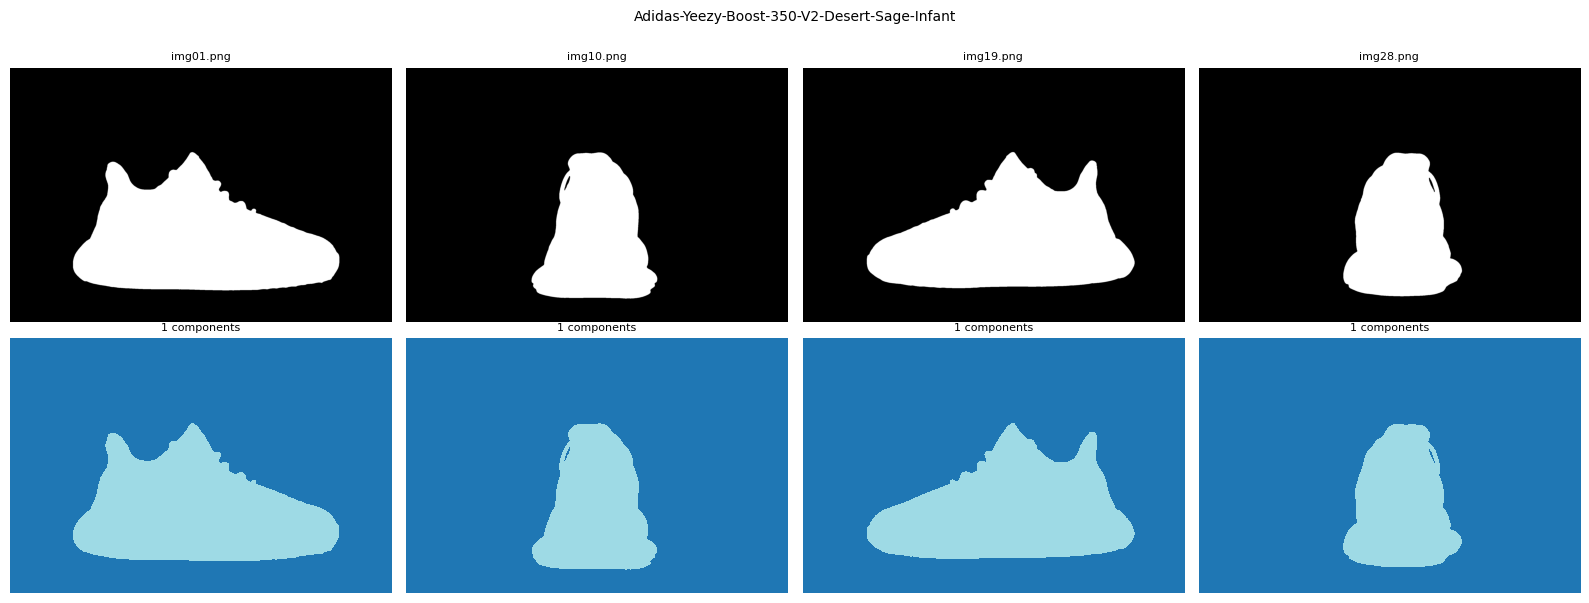

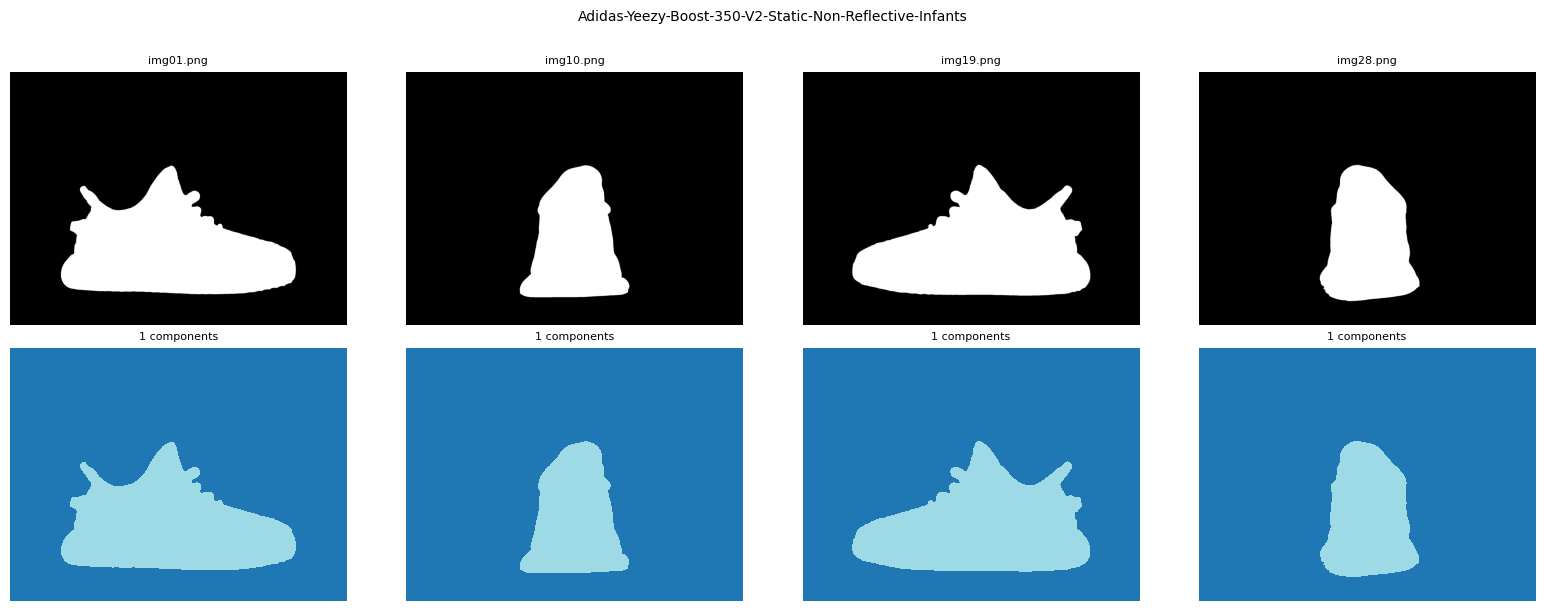

In [69]:
# ── D.3  Visual debugging ──────────────────────────────────────────────────────

def show_mask_debug(shoe_dir: Path, n_views: int = 4, fg_thresh: int = 128) -> None:
    """Display raw masks + connected-component overlay for *n_views* of one shoe."""
    mask_dir = shoe_dir / "masks"
    if not mask_dir.is_dir():
        print(f"  No masks dir for {shoe_dir.name}")
        return
    masks = sorted([f for f in mask_dir.iterdir() if f.suffix.lower() in cfg.mask_extensions])
    chosen = masks[:: max(1, len(masks) // n_views)][:n_views]

    fig, axes = plt.subplots(2, len(chosen), figsize=(4 * len(chosen), 6))
    if len(chosen) == 1:
        axes = axes[:, np.newaxis]
    for i, mp in enumerate(chosen):
        gray = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        fg = (gray >= fg_thresh).astype(np.uint8)
        n_labels, labels, _, _ = cv2.connectedComponentsWithStats(fg, connectivity=4)

        axes[0, i].imshow(gray, cmap="gray", vmin=0, vmax=255)
        axes[0, i].set_title(mp.name, fontsize=8)
        axes[0, i].axis("off")

        cc_vis = (labels % 20 + 1) * (labels > 0)   # colour by label
        axes[1, i].imshow(cc_vis, cmap="tab20", interpolation="nearest")
        axes[1, i].set_title(f"{n_labels - 1} components", fontsize=8)
        axes[1, i].axis("off")

    fig.suptitle(f"{shoe_dir.name}", fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

# Show debug for the first two sample shoes
for s in sample_shoes[:2]:
    show_mask_debug(s["shoe_dir"])

### D.4 — Full-dataset segmentation analysis

Run the mask analysis on **all** shoes. This cell may take a minute.

In [70]:
# ── D.4  Full segmentation run ──────────────────────────────────────────────────

seg_rows = []
for s in tqdm(shoe_info, desc="Segmentation analysis"):
    if s["mask_dir"]:
        seg_rows.append(analyse_shoe_masks(s["shoe_id"], s["mask_dir"], cfg.mask_fg_threshold))
    else:
        seg_rows.append({"shoe_id": s["shoe_id"], "n_masks_found": 0})
seg_metrics = pd.DataFrame(seg_rows)
log.info("Segmentation metrics computed for %d shoes", len(seg_metrics))
seg_metrics.round(4)

Segmentation analysis: 100%|██████████| 20/20 [00:17<00:00,  1.13it/s]
16:05:11  INFO      Segmentation metrics computed for 20 shoes


,shoe_id,n_masks_found,n_valid_masks,fg_area_mean,fg_area_median,fg_area_std,fg_area_min,fg_area_max,frac_tiny,frac_huge,mean_n_components,median_largest_cc_frac,frac_multiblob,frac_boundary_touch,seg_consistency_score
0,Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant,36,36,0.1893,0.1999,0.0360,0.1222,0.2323,0.0,0.0,1.0000,1.0,0.0000,0.0,0.8098
1,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,36,36,0.1767,0.1883,0.0342,0.1121,0.2173,0.0,0.0,1.0000,1.0,0.0000,0.0,0.8064
2,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,36,36,0.1353,0.1438,0.0287,0.0806,0.1671,0.0,0.0,1.0000,1.0,0.0000,0.0,0.7881
3,Air-Jordan-1-Mid-Wear-Away-Chicago-Gs,36,36,0.1927,0.2025,0.0410,0.1155,0.2402,0.0,0.0,1.0000,1.0,0.0000,0.0,0.7872
4,Air-Jordan-1-Retro-High-Hyper-Royal-Smoke-Grey-Gs,36,36,0.2905,0.3083,0.0672,0.1584,0.3727,0.0,0.0,1.0000,1.0,0.0000,0.0,0.7688
5,Air-Jordan-1-Retro-High-Og-Washed-Black-Gs,36,36,0.2358,0.2457,0.0469,0.1435,0.2913,0.0,0.0,1.0000,1.0,0.0000,0.0,0.8013
6,Air-Jordan-1-Retro-High-Og-White-Cement-Gs,36,36,0.2745,0.2881,0.0601,0.1541,0.3494,0.0,0.0,1.0000,1.0,0.0000,0.0,0.7812
7,Air-Jordan-12-Retro-Arctic-Punch-Gs,36,36,0.3035,0.3152,0.0599,0.1916,0.3753,0.0,0.0,1.0000,1.0,0.0000,0.0,0.8026
8,Air-Jordan-13-Retro-Houndstooth-Gs,36,36,0.2683,0.2807,0.0536,0.1662,0.3323,0.0,0.0,1.0833,1.0,0.0556,0.0,0.8001
9,Air-Jordan-5-Retro-Plaid-Gs,36,36,0.2128,0.2199,0.0428,0.1305,0.2654,0.0,0.0,1.0278,1.0,0.0278,0.0,0.7988


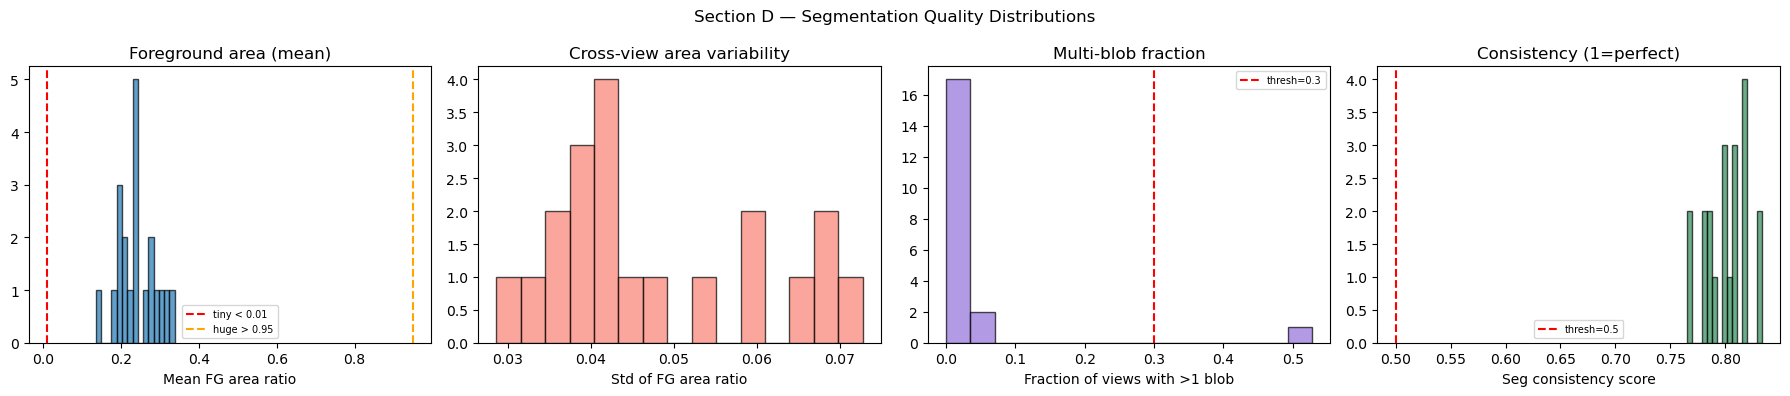

In [71]:
# ── D.5  Segmentation distribution plots ───────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(seg_metrics["fg_area_mean"].dropna(), bins=15, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Mean FG area ratio")
axes[0].set_title("Foreground area (mean)")
axes[0].axvline(cfg.fg_area_tiny, color="r", ls="--", label=f"tiny < {cfg.fg_area_tiny}")
axes[0].axvline(cfg.fg_area_huge, color="orange", ls="--", label=f"huge > {cfg.fg_area_huge}")
axes[0].legend(fontsize=7)

axes[1].hist(seg_metrics["fg_area_std"].dropna(), bins=15, edgecolor="k", alpha=0.7, color="salmon")
axes[1].set_xlabel("Std of FG area ratio")
axes[1].set_title("Cross-view area variability")

axes[2].hist(seg_metrics["frac_multiblob"].dropna(), bins=15, edgecolor="k", alpha=0.7, color="mediumpurple")
axes[2].set_xlabel("Fraction of views with >1 blob")
axes[2].set_title("Multi-blob fraction")
axes[2].axvline(cfg.max_multiblob_frac, color="r", ls="--", label=f"thresh={cfg.max_multiblob_frac}")
axes[2].legend(fontsize=7)

axes[3].hist(seg_metrics["seg_consistency_score"].dropna(), bins=15, edgecolor="k", alpha=0.7, color="seagreen")
axes[3].set_xlabel("Seg consistency score")
axes[3].set_title("Consistency (1=perfect)")
axes[3].axvline(cfg.min_seg_consistency, color="r", ls="--", label=f"thresh={cfg.min_seg_consistency}")
axes[3].legend(fontsize=7)

plt.suptitle("Section D — Segmentation Quality Distributions", fontsize=12)
plt.tight_layout()
fig.savefig(cfg.figures_dir / "seg_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section E — COLMAP Pose Quality Metrics

**What:** Parse COLMAP text outputs (`cameras.txt`, `images.txt`, `points3D.txt`) and compute per-shoe reconstruction quality metrics.

**Turntable geometry note:**  
This is a **horizontal-orbit turntable dataset**.  Cameras rotate around the vertical axis only—there are no top or bottom views, and camera centres are expected to lie on a near-planar ring.

Metrics computed:

| metric | meaning |
|---|---|
| `registration_rate` | fraction of input images registered by COLMAP |
| `mean_reproj_error` | mean reprojection error across all sparse points |
| `n_sparse_points` | total 3-D points in the sparse model |
| `cam_radius_mean/std/cv` | distance from object centre—should be stable |
| `pca_ratio_12` | λ₂/λ₁ of camera-centre PCA. Near 1 → healthy ring. Low → line collapse |
| `pca_ratio_13` | λ₃/λ₁ of camera-centre PCA. Near 0 → planar (expected & good). High → off-plane drift |

**Important:**  For this dataset a *near-zero* `pca_ratio_13` is the **expected good case**, not a degeneracy.  The dangerous layout is a *line-like collapse* (`pca_ratio_12` ≈ 0).

**Format:** COLMAP standard text output (two-line-per-image in `images.txt`, one-line-per-point in `points3D.txt`).

In [72]:
# ── E.1  COLMAP text parsers ────────────────────────────────────────────────────

@dataclass
class ColmapCamera:
    camera_id: int
    model: str
    width: int
    height: int
    params: List[float]

@dataclass
class ColmapImage:
    image_id: int
    qvec: np.ndarray        # quaternion (w, x, y, z)
    tvec: np.ndarray        # translation
    camera_id: int
    name: str
    n_observations: int     # from 2D point line
    mean_reproj_error: float  # placeholder – computed from points3D

@dataclass
class ColmapPoint3D:
    point_id: int
    xyz: np.ndarray
    rgb: np.ndarray
    error: float
    track_length: int


def parse_cameras_txt(path: Path) -> List[ColmapCamera]:
    """Parse COLMAP cameras.txt → list of ColmapCamera."""
    cameras = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            cameras.append(ColmapCamera(
                camera_id=int(parts[0]),
                model=parts[1],
                width=int(parts[2]),
                height=int(parts[3]),
                params=[float(x) for x in parts[4:]],
            ))
    return cameras


def focal_length_from_camera(cam: ColmapCamera) -> float:
    """Extract a scalar focal length (pixels) from a ColmapCamera.

    Handles the standard COLMAP camera models:
      - Single-focal models (SIMPLE_PINHOLE, SIMPLE_RADIAL, RADIAL):
            params[0] = f
      - Two-focal models (PINHOLE, OPENCV, OPENCV_FISHEYE, FULL_OPENCV):
            params[0] = fx, params[1] = fy  →  returns (fx + fy) / 2
    """
    single_focal = {"SIMPLE_PINHOLE", "SIMPLE_RADIAL", "RADIAL"}
    dual_focal = {"PINHOLE", "OPENCV", "OPENCV_FISHEYE", "FULL_OPENCV"}
    if cam.model in single_focal:
        return cam.params[0]
    elif cam.model in dual_focal:
        return (cam.params[0] + cam.params[1]) / 2.0
    else:
        log.warning("Unknown camera model %s – using params[0] as focal length", cam.model)
        return cam.params[0]


def parse_images_txt(path: Path) -> List[ColmapImage]:
    """Parse COLMAP images.txt → list of ColmapImage.
    
    Format: two lines per image.
      Line 1: IMAGE_ID QW QX QY QZ TX TY TZ CAMERA_ID NAME
      Line 2: POINTS2D[] as (X, Y, POINT3D_ID)
    """
    images = []
    with open(path) as f:
        lines = [l.strip() for l in f if l.strip() and not l.startswith("#")]
    # Process in pairs
    for i in range(0, len(lines) - 1, 2):
        parts = lines[i].split()
        if len(parts) < 10:
            continue
        image_id = int(parts[0])
        qvec = np.array([float(parts[j]) for j in range(1, 5)])
        tvec = np.array([float(parts[j]) for j in range(5, 8)])
        camera_id = int(parts[8])
        name = parts[9]
        # Count observations from line 2
        obs_parts = lines[i + 1].split()
        n_obs = len(obs_parts) // 3  # each observation is (X, Y, POINT3D_ID)
        images.append(ColmapImage(
            image_id=image_id, qvec=qvec, tvec=tvec,
            camera_id=camera_id, name=name,
            n_observations=n_obs, mean_reproj_error=0.0,
        ))
    return images


def parse_points3d_txt(path: Path) -> List[ColmapPoint3D]:
    """Parse COLMAP points3D.txt → list of ColmapPoint3D.
    
    Format: POINT3D_ID X Y Z R G B ERROR TRACK[] as (IMAGE_ID POINT2D_IDX)
    """
    points = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 8:
                continue
            pid = int(parts[0])
            xyz = np.array([float(parts[1]), float(parts[2]), float(parts[3])])
            rgb = np.array([int(parts[4]), int(parts[5]), int(parts[6])])
            error = float(parts[7])
            track_entries = parts[8:]
            track_length = len(track_entries) // 2
            points.append(ColmapPoint3D(
                point_id=pid, xyz=xyz, rgb=rgb,
                error=error, track_length=track_length,
            ))
    return points


def qvec_to_rotmat(qvec: np.ndarray) -> np.ndarray:
    """Convert COLMAP quaternion (w,x,y,z) to 3x3 rotation matrix."""
    return Rotation.from_quat([qvec[1], qvec[2], qvec[3], qvec[0]]).as_matrix()


def camera_center_from_image(img: ColmapImage) -> np.ndarray:
    """Compute world-space camera center: C = -R^T @ t."""
    R = qvec_to_rotmat(img.qvec)
    return -R.T @ img.tvec


log.info("COLMAP parsers defined.")


16:05:12  INFO      COLMAP parsers defined.


In [73]:
# ── E.2  Per-shoe COLMAP analysis ──────────────────────────────────────────────

def analyse_shoe_colmap(shoe_id: str, colmap_dir: Path,
                        num_images: int) -> Dict[str, Any]:
    """Parse COLMAP outputs and compute pose-quality metrics for one shoe.

    Turntable interpretation
    ────────────────────────
    Camera centres should form a near-planar ring.
    • pca_ratio_12 ≈ 1  → healthy 2-D ring.
    • pca_ratio_13 ≈ 0  → planar (expected & good for turntable).
    • cam_radius_cv low  → cameras stay at a consistent distance.

    Note: points3D.txt stores per-point reprojection errors in normalised
    image coordinates.  We multiply by the focal length (from cameras.txt)
    to convert to pixel-space before reporting.
    """
    result: Dict[str, Any] = {"shoe_id": shoe_id}

    nan_keys = (
        "n_registered", "registration_rate", "mean_reproj_error",
        "median_reproj_error", "n_sparse_points", "mean_track_length",
        "cam_radius_mean", "cam_radius_std", "cam_radius_cv",
        "pca_ratio_12", "pca_ratio_13",
        "cam_center_x", "cam_center_y", "cam_center_z",
        "object_center_x", "object_center_y", "object_center_z",
    )

    # ── Parse cameras (needed for focal-length scaling) ────────────────────
    cameras_txt = colmap_dir / "cameras.txt"
    cameras = []
    focal = None
    if cameras_txt.is_file():
        try:
            cameras = parse_cameras_txt(cameras_txt)
            if cameras:
                focal = float(np.mean([focal_length_from_camera(c) for c in cameras]))
        except Exception as e:
            log.warning("%s: cameras.txt parse error: %s", shoe_id, e)
    if focal is None:
        log.warning("%s: no focal length available – reproj errors will stay in normalised coords", shoe_id)
        focal = 1.0

    # ── Parse images ───────────────────────────────────────────────────────
    images_txt = colmap_dir / "images.txt"
    if not images_txt.is_file():
        log.warning("%s: images.txt not found", shoe_id)
        for k in nan_keys:
            result[k] = np.nan
        result["colmap_ok"] = False
        return result

    try:
        images = parse_images_txt(images_txt)
    except Exception as e:
        log.error("%s: failed to parse images.txt: %s", shoe_id, e)
        for k in nan_keys:
            result[k] = np.nan
        result["colmap_ok"] = False
        return result

    n_registered = len(images)
    result["n_registered"] = n_registered
    result["registration_rate"] = n_registered / max(num_images, 1)

    # ── Camera centers ─────────────────────────────────────────────────────
    cam_centers = np.array([camera_center_from_image(im) for im in images])
    cam_centroid = cam_centers.mean(axis=0)
    result["cam_center_x"] = float(cam_centroid[0])
    result["cam_center_y"] = float(cam_centroid[1])
    result["cam_center_z"] = float(cam_centroid[2])

    # ── Parse points3D ────────────────────────────────────────────────────
    points_txt = colmap_dir / "points3D.txt"
    points = []
    if points_txt.is_file():
        try:
            points = parse_points3d_txt(points_txt)
        except Exception as e:
            log.warning("%s: points3D parse error: %s", shoe_id, e)

    result["n_sparse_points"] = len(points)

    if points:
        raw_errors = np.array([p.error for p in points])
        errors_px = raw_errors * focal  # convert to pixel-space
        tracks = np.array([p.track_length for p in points])
        result["mean_reproj_error"]   = float(errors_px.mean())
        result["median_reproj_error"] = float(np.median(errors_px))
        result["mean_track_length"]   = float(tracks.mean())

        # Object center from sparse points
        pts_xyz = np.array([p.xyz for p in points])
        obj_center = pts_xyz.mean(axis=0)
    else:
        result["mean_reproj_error"]   = np.nan
        result["median_reproj_error"] = np.nan
        result["mean_track_length"]   = np.nan
        obj_center = cam_centroid

    result["object_center_x"] = float(obj_center[0])
    result["object_center_y"] = float(obj_center[1])
    result["object_center_z"] = float(obj_center[2])

    # ── Camera radius stats (distance from object center) ─────────────────
    dists = np.linalg.norm(cam_centers - obj_center, axis=1)
    result["cam_radius_mean"] = float(dists.mean())
    result["cam_radius_std"]  = float(dists.std())
    result["cam_radius_cv"]   = float(dists.std() / max(dists.mean(), 1e-12))

    # ── PCA of camera centres — orbit-shape diagnostics ───────────────────
    #
    # For a turntable dataset the cameras sit on a planar ring.
    #   ev_sorted[0] ≈ ev_sorted[1] ≫ ev_sorted[2]
    #
    # pca_ratio_12 = ev2 / ev1  → close to 1 means a healthy 2-D ring.
    #                              Much below 1 means cameras collapse
    #                              toward a line (BAD).
    # pca_ratio_13 = ev3 / ev1  → close to 0 means planar (EXPECTED).
    #                              Much above 0 means unexpected out-of-
    #                              plane spread (suspicious).
    if n_registered >= 3:
        pca = PCA(n_components=3).fit(cam_centers)
        ev = pca.explained_variance_
        ev_sorted = np.sort(ev)[::-1]  # largest first
        result["pca_ratio_12"] = float(ev_sorted[1] / max(ev_sorted[0], 1e-12))
        result["pca_ratio_13"] = float(ev_sorted[2] / max(ev_sorted[0], 1e-12))
    else:
        result["pca_ratio_12"] = np.nan
        result["pca_ratio_13"] = np.nan

    result["colmap_ok"] = True
    return result

log.info("COLMAP analysis function defined.")


16:05:12  INFO      COLMAP analysis function defined.


### E.2  Quick-test COLMAP parsing on a sample

Run on `cfg.sample_n` shoes to verify the parser and metrics pipeline.
Watch for `nan` values that might indicate a missing file or parse glitch.

In [93]:
# ── E.2  Sample COLMAP run ─────────────────────────────────────────────────────

sample_shoes = shoes[:]

colmap_rows = []
for sid in sample_shoes:
    shoe_dir = cfg.data_root / sid
    colmap_dir = shoe_dir / "colmap"
    n_images = len(list((shoe_dir / "images").glob("*")))
    row = analyse_shoe_colmap(sid, colmap_dir, n_images)
    colmap_rows.append(row)

df_colmap_sample = pd.DataFrame(colmap_rows)
display_cols = [
    "shoe_id", "n_registered", "registration_rate",
    "mean_reproj_error", "median_reproj_error",
    "n_sparse_points", "mean_track_length",
    "cam_radius_mean", "cam_radius_cv",
    "pca_ratio_12", "pca_ratio_13",
]
df_colmap_sample[[c for c in display_cols if c in df_colmap_sample.columns]]

,shoe_id,n_registered,registration_rate,mean_reproj_error,median_reproj_error,n_sparse_points,mean_track_length,cam_radius_mean,cam_radius_cv,pca_ratio_12,pca_ratio_13
0,Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant,36,1.0,0.291733,0.239898,40221,4.738072,3.707071,0.007291,0.997922,2.855409e-07
1,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,36,1.0,0.302880,0.214467,28624,4.860152,3.760245,0.006927,0.998458,2.796594e-07
2,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,36,1.0,0.244637,0.169005,32850,4.669041,3.701782,0.011878,0.998778,3.674122e-07
3,Air-Jordan-1-Mid-Wear-Away-Chicago-Gs,36,1.0,0.252379,0.201709,34840,5.296470,3.700535,0.027271,0.998763,1.742752e-07
4,Air-Jordan-1-Retro-High-Hyper-Royal-Smoke-Grey-Gs,36,1.0,0.314266,0.227660,31279,4.853736,3.704145,0.033044,0.998996,9.764385e-08
5,Air-Jordan-1-Retro-High-Og-Washed-Black-Gs,36,1.0,0.255765,0.184361,31534,4.408289,3.668805,0.028803,0.998606,1.422597e-07
6,Air-Jordan-1-Retro-High-Og-White-Cement-Gs,36,1.0,2668.973621,1776.483522,30861,5.581187,3.726212,0.021752,0.998840,6.103366e-07
7,Air-Jordan-12-Retro-Arctic-Punch-Gs,36,1.0,0.336748,0.260446,34852,5.201079,3.742291,0.032856,0.997518,1.403880e-07
8,Air-Jordan-13-Retro-Houndstooth-Gs,36,1.0,0.204478,0.148374,35755,4.867235,3.673673,0.025076,0.998054,1.982938e-07
9,Air-Jordan-5-Retro-Plaid-Gs,36,1.0,0.261316,0.165141,35290,4.995664,3.755027,0.029322,0.997950,4.879539e-07


### E.3  Full dataset COLMAP analysis

Once the sample looks correct, run on all shoes.

In [75]:
# ── E.3  Full COLMAP run ───────────────────────────────────────────────────────

colmap_rows_all = []
for sid in tqdm(shoes, desc="COLMAP analysis"):
    shoe_dir = cfg.data_root / sid
    colmap_dir = shoe_dir / "colmap"
    n_images = len(list((shoe_dir / "images").glob("*")))
    row = analyse_shoe_colmap(sid, colmap_dir, n_images)
    colmap_rows_all.append(row)

df_colmap = pd.DataFrame(colmap_rows_all)
log.info("COLMAP metrics collected for %d shoes.", len(df_colmap))
df_colmap.describe()

COLMAP analysis: 100%|██████████| 20/20 [00:06<00:00,  3.27it/s]
16:05:19  INFO      COLMAP metrics collected for 20 shoes.


,n_registered,registration_rate,cam_center_x,cam_center_y,cam_center_z,n_sparse_points,mean_reproj_error,median_reproj_error,mean_track_length,object_center_x,object_center_y,object_center_z,cam_radius_mean,cam_radius_std,cam_radius_cv,pca_ratio_12,pca_ratio_13
count,20.0,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,2.000000e+01
mean,36.0,1.0,0.001711,0.000417,-0.000344,32391.000000,133.725542,89.029169,4.862598,-0.060470,0.175339,-0.003201,3.722103,0.068885,0.018532,0.995101,1.554040e-05
std,0.0,0.0,0.007471,0.001585,0.000726,2914.938963,596.735480,397.185543,0.446274,0.086931,0.087271,0.015754,0.032376,0.039678,0.010717,0.013596,6.800279e-05
min,36.0,1.0,-0.001095,-0.000249,-0.002708,28624.000000,0.204478,0.148374,4.130977,-0.171827,0.058237,-0.029839,3.668805,0.019220,0.005207,0.937508,5.969858e-08
25%,36.0,1.0,0.000009,-0.000110,-0.000551,30355.000000,0.254918,0.192593,4.603853,-0.134047,0.126842,-0.014092,3.700340,0.036250,0.009678,0.997495,1.733076e-07
50%,36.0,1.0,0.000098,0.000063,-0.000329,31262.500000,0.304507,0.221064,4.863694,-0.056690,0.150054,-0.002491,3.710664,0.061225,0.016283,0.998279,3.025466e-07
75%,36.0,1.0,0.000258,0.000231,-0.000038,34843.000000,0.332939,0.257032,5.165458,-0.031299,0.207861,0.006507,3.750933,0.102107,0.027654,0.998767,4.633229e-07
max,36.0,1.0,0.033418,0.007078,0.001389,40221.000000,2668.973621,1776.483522,5.678266,0.154685,0.375445,0.028724,3.773369,0.149676,0.040456,0.999469,3.044508e-04


### E.4  COLMAP Visualisations

**Left:** Reprojection error distribution — lower is better.  
**Centre:** Registration rate per shoe — should be 1.0 if COLMAP used every image.  
**Right:** Sparse point count — more points → denser support for reconstruction.  
**Below:** 3-D camera-centre scatter for a single shoe to visually confirm turntable ring geometry.

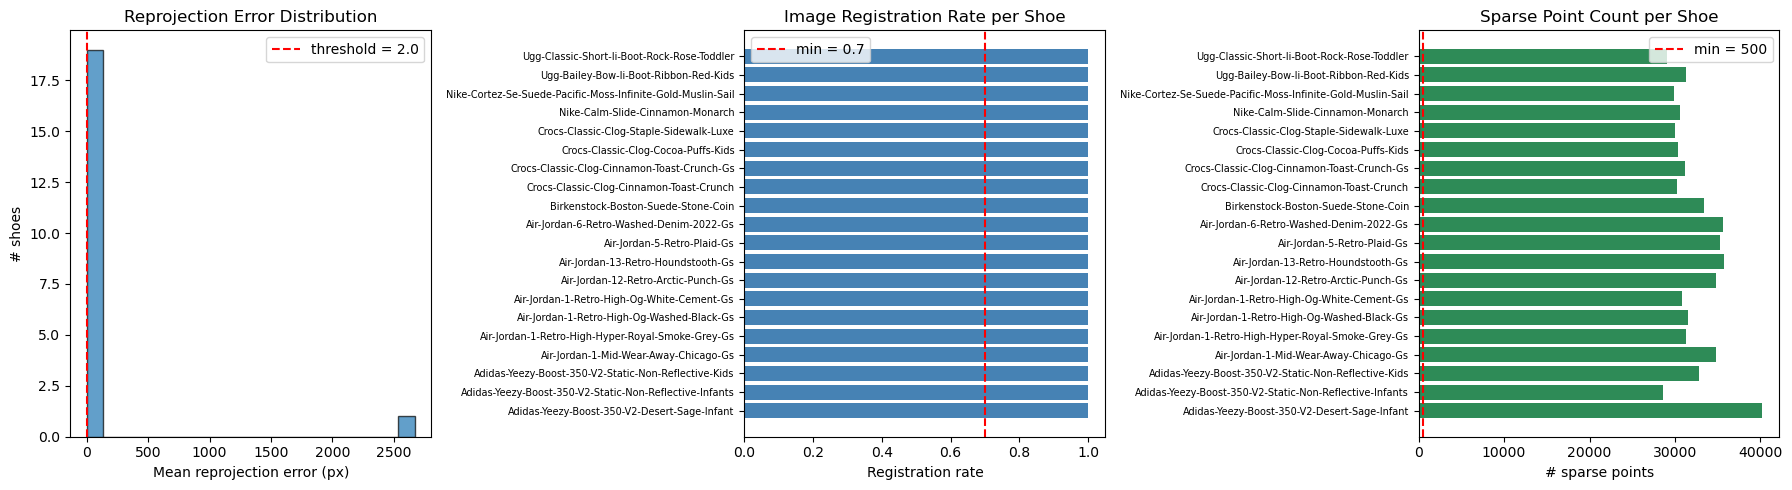

In [76]:
# ── E.4  COLMAP distribution plots ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Reprojection error histogram
ax = axes[0]
vals = df_colmap["mean_reproj_error"].dropna()
ax.hist(vals, bins=20, edgecolor="k", alpha=0.7)
ax.axvline(cfg.max_mean_reproj_error, color="red", ls="--",
           label=f"threshold = {cfg.max_mean_reproj_error}")
ax.set_xlabel("Mean reprojection error (px)")
ax.set_ylabel("# shoes")
ax.set_title("Reprojection Error Distribution")
ax.legend()

# (b) Registration rate bar
ax = axes[1]
ax.barh(df_colmap["shoe_id"], df_colmap["registration_rate"], color="steelblue")
ax.axvline(cfg.min_registration_rate, color="red", ls="--",
           label=f"min = {cfg.min_registration_rate}")
ax.set_xlabel("Registration rate")
ax.set_title("Image Registration Rate per Shoe")
ax.legend()
ax.tick_params(axis="y", labelsize=7)

# (c) Sparse point count
ax = axes[2]
ax.barh(df_colmap["shoe_id"], df_colmap["n_sparse_points"], color="seagreen")
ax.axvline(cfg.min_sparse_points, color="red", ls="--",
           label=f"min = {cfg.min_sparse_points}")
ax.set_xlabel("# sparse points")
ax.set_title("Sparse Point Count per Shoe")
ax.legend()
ax.tick_params(axis="y", labelsize=7)

fig.tight_layout()
fig.savefig(cfg.artifact_dir / "colmap_overview.png", dpi=150, bbox_inches="tight")
plt.show()

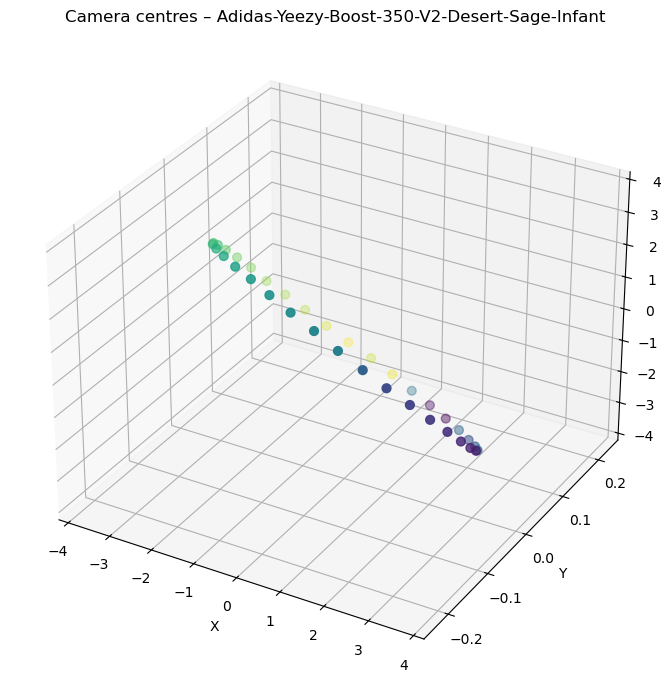

In [77]:
# ── E.4b  Camera center 3-D scatter for one shoe ──────────────────────────────

def plot_camera_ring(shoe_id: str, colmap_dir: Path):
    """3-D scatter of camera centers for visual geometry check."""
    images = parse_images_txt(colmap_dir / "images.txt")
    centers = np.array([camera_center_from_image(im) for im in images])

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2],
               c=np.arange(len(centers)), cmap="viridis", s=40)
    ax.set_title(f"Camera centres – {shoe_id}")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    fig.tight_layout()
    plt.show()

# Plot for first shoe (spot check)
plot_camera_ring(shoes[0], cfg.data_root / shoes[0] / "colmap")

---

## Section F — View Coverage Metrics  (orbit-plane aware)

This is a **turntable-style dataset**: cameras orbit horizontally around the
shoe.  We do **not** assume COLMAP world axes align with the capture axes, so
we fit the dominant orbit plane directly from the camera centres (SVD/PCA)
and measure coverage *within that plane*.

**Metrics per shoe:**

| metric | meaning |
|---|---|
| `azimuth_coverage` | fraction of 360° azimuth bins occupied **in the fitted orbit plane** |
| `max_azimuth_gap_deg` | largest angular gap between consecutive cameras **in the orbit plane** |
| `elevation_range_deg` | out-of-plane elevation span (should be small for turntable) |
| `elevation_mean_deg` | mean out-of-plane elevation (sanity check, expect near 0°) |
| `orbit_thickness_ratio` | orbit thickness / in-plane spread (lower = flatter = expected) |

**What is NOT penalised:** missing top views, missing bottom views, low true
elevation diversity.  Those are inherent properties of a turntable capture
and not quality defects.

**What IS penalised:** poor in-plane coverage, large orbit gaps, unexpected
out-of-plane thickness (suggesting a broken orbit or misregistered frames).

In [78]:
# ── F.1  View-coverage analysis function ───────────────────────────────────────

def fit_orbit_frame(cam_centers: np.ndarray) -> Dict[str, Any]:
    """Estimate a local camera-orbit frame from the camera centres.

    We fit the dominant orbit plane with SVD/PCA so that azimuth/elevation
    are measured in a scene-adaptive frame rather than a fixed world plane.
    This makes the coverage metrics robust to arbitrary COLMAP axis layouts.
    """
    cam_centers = np.asarray(cam_centers, dtype=float)
    cam_centroid = cam_centers.mean(axis=0)

    if cam_centers.shape[0] < 3:
        return {
            "centroid": cam_centroid,
            "axis_u": np.array([1.0, 0.0, 0.0]),
            "axis_v": np.array([0.0, 1.0, 0.0]),
            "axis_n": np.array([0.0, 0.0, 1.0]),
            "thickness_ratio": np.nan,
        }

    X = cam_centers - cam_centroid
    _, s, vh = np.linalg.svd(X, full_matrices=False)
    axis_u = vh[0]
    axis_v = vh[1]
    axis_n = vh[2]
    thickness_ratio = float(s[2] / max(s[1], 1e-12))

    return {
        "centroid": cam_centroid,
        "axis_u": axis_u,
        "axis_v": axis_v,
        "axis_n": axis_n,
        "thickness_ratio": thickness_ratio,
    }


def analyse_view_coverage(shoe_id: str, colmap_dir: Path,
                          azimuth_bins: int = 36) -> Dict[str, Any]:
    """Compute orbit-aware view-coverage metrics from camera centres."""
    result: Dict[str, Any] = {"shoe_id": shoe_id}
    metric_keys = (
        "azimuth_coverage", "max_azimuth_gap_deg",
        "elevation_range_deg", "elevation_mean_deg",
        "orbit_thickness_ratio",
    )

    images_txt = colmap_dir / "images.txt"
    if not images_txt.is_file():
        for k in metric_keys:
            result[k] = np.nan
        return result

    images = parse_images_txt(images_txt)
    if len(images) < 2:
        for k in metric_keys:
            result[k] = np.nan
        return result

    cam_centers = np.array([camera_center_from_image(im) for im in images], dtype=float)

    # ── Object centre from sparse points (or camera centroid) ──────────
    points_txt = colmap_dir / "points3D.txt"
    if points_txt.is_file():
        try:
            pts = parse_points3d_txt(points_txt)
            if pts:
                obj_center = np.mean([p.xyz for p in pts], axis=0)
            else:
                obj_center = cam_centers.mean(axis=0)
        except Exception:
            obj_center = cam_centers.mean(axis=0)
    else:
        obj_center = cam_centers.mean(axis=0)

    orbit = fit_orbit_frame(cam_centers)
    rel = cam_centers - obj_center
    u = rel @ orbit["axis_u"]
    v = rel @ orbit["axis_v"]
    n = rel @ orbit["axis_n"]
    planar_r = np.sqrt(u * u + v * v)

    # Azimuth is the angle inside the fitted orbit plane.  Elevation is the
    # out-of-plane angle relative to that same plane.
    azim = np.degrees(np.arctan2(v, u))
    elev = np.degrees(np.arctan2(n, np.maximum(planar_r, 1e-9)))

    # ── Azimuth coverage ───────────────────────────────────────────────
    bin_edges = np.linspace(-180, 180, azimuth_bins + 1)
    hist, _ = np.histogram(azim, bins=bin_edges)
    occupied = (hist > 0).sum()
    result["azimuth_coverage"] = float(occupied / azimuth_bins)

    # ── Largest azimuth gap ────────────────────────────────────────────
    sorted_az = np.sort(azim)
    gaps = np.diff(sorted_az)
    wrap_gap = 360.0 - (sorted_az[-1] - sorted_az[0])
    all_gaps = np.append(gaps, wrap_gap)
    result["max_azimuth_gap_deg"] = float(all_gaps.max())

    # ── Out-of-plane elevation stats ───────────────────────────────────
    result["elevation_range_deg"] = float(elev.max() - elev.min())
    result["elevation_mean_deg"]  = float(elev.mean())
    result["orbit_thickness_ratio"] = orbit["thickness_ratio"]

    return result

log.info("View-coverage analysis function defined.")

16:05:21  INFO      View-coverage analysis function defined.


### F.2  Quick-test view coverage on sample

Run on `cfg.sample_n` shoes to spot-check before the full sweep.

In [79]:
# ── F.2  Sample view-coverage run ──────────────────────────────────────────────

vc_rows = []
for sid in shoes[:cfg.sample_n]:
    row = analyse_view_coverage(sid, cfg.data_root / sid / "colmap")
    vc_rows.append(row)

df_vc_sample = pd.DataFrame(vc_rows)
df_vc_sample

,shoe_id,azimuth_coverage,max_azimuth_gap_deg,elevation_range_deg,elevation_mean_deg,orbit_thickness_ratio
0,Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant,1.0,10.257649,0.132851,-4.038319,0.000535
1,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,1.0,10.356449,0.090739,2.217086,0.000529
2,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,1.0,10.184895,0.124727,2.115076,0.000607


### F.3  Full dataset view coverage

In [80]:
# ── F.3  Full view-coverage run ─────────────────────────────────────────────────

vc_rows_all = []
for sid in tqdm(shoes, desc="View coverage"):
    row = analyse_view_coverage(sid, cfg.data_root / sid / "colmap")
    vc_rows_all.append(row)

df_vc = pd.DataFrame(vc_rows_all)
log.info("View-coverage metrics collected for %d shoes.", len(df_vc))
df_vc.describe()

View coverage: 100%|██████████| 20/20 [00:06<00:00,  3.26it/s]
16:05:28  INFO      View-coverage metrics collected for 20 shoes.


,azimuth_coverage,max_azimuth_gap_deg,elevation_range_deg,elevation_mean_deg,orbit_thickness_ratio
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.986111,10.816660,0.390560,0.720178,0.001424
std,0.014250,2.106815,1.058349,2.958594,0.003910
min,0.972222,10.136928,0.090739,-4.038319,0.000245
25%,0.972222,10.304584,0.130578,-2.011320,0.000417
50%,0.986111,10.360005,0.146521,1.702391,0.000550
75%,1.000000,10.436064,0.168354,2.459193,0.000681
max,1.000000,19.756671,4.882177,5.697152,0.018021


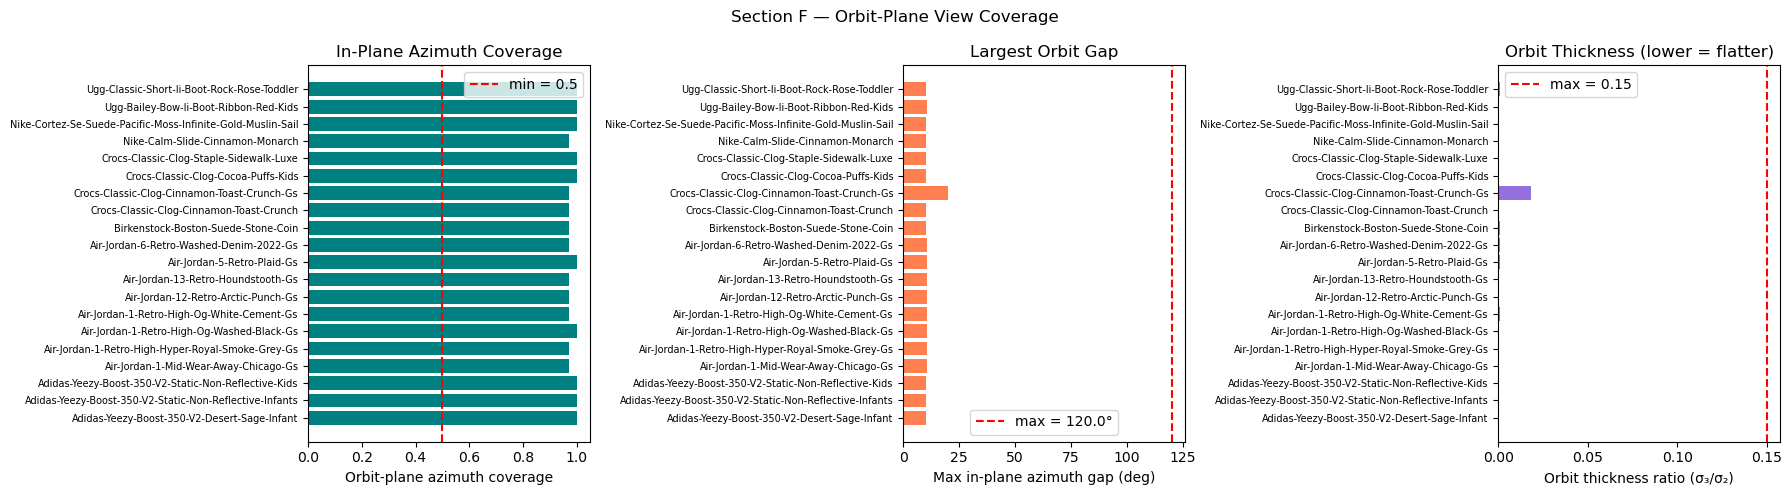

In [81]:
# ── F.4  View-coverage visualisations ──────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Orbit-plane azimuth coverage
ax = axes[0]
ax.barh(df_vc["shoe_id"], df_vc["azimuth_coverage"], color="teal")
ax.axvline(cfg.min_orbit_coverage, color="red", ls="--",
           label=f"min = {cfg.min_orbit_coverage}")
ax.set_xlabel("Orbit-plane azimuth coverage")
ax.set_title("In-Plane Azimuth Coverage")
ax.legend(); ax.tick_params(axis="y", labelsize=7)

# (b) Largest orbit gap
ax = axes[1]
ax.barh(df_vc["shoe_id"], df_vc["max_azimuth_gap_deg"], color="coral")
ax.axvline(cfg.max_orbit_gap_deg, color="red", ls="--",
           label=f"max = {cfg.max_orbit_gap_deg}°")
ax.set_xlabel("Max in-plane azimuth gap (deg)")
ax.set_title("Largest Orbit Gap")
ax.legend(); ax.tick_params(axis="y", labelsize=7)

# (c) Orbit thickness ratio  (lower = flatter = expected for turntable)
ax = axes[2]
ax.barh(df_vc["shoe_id"], df_vc["orbit_thickness_ratio"], color="mediumpurple")
ax.axvline(cfg.max_orbit_thickness_ratio, color="red", ls="--",
           label=f"max = {cfg.max_orbit_thickness_ratio}")
ax.set_xlabel("Orbit thickness ratio (σ₃/σ₂)")
ax.set_title("Orbit Thickness (lower = flatter)")
ax.legend(); ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Section F — Orbit-Plane View Coverage", fontsize=12)
fig.tight_layout()
fig.savefig(cfg.artifact_dir / "view_coverage_overview.png", dpi=150,
            bbox_inches="tight")
plt.show()

---

## Section G — Unified Quality Table & Decisions

Merge all per-shoe metrics (segmentation, COLMAP, view coverage) into one
table and apply **turntable-aware** threshold rules.

### Verdict levels

| verdict | meaning |
|---|---|
| **pass** | clean horizontal orbit, consistent masks, good COLMAP support |
| **borderline** | one or two soft violations — inspect before use |
| **reject** | at least one hard violation — do **not** use without fixing |

### What we reject for (turntable-specific)

* low registration rate
* too few sparse points or high reprojection error
* poor mask consistency
* **line-like camera collapse** (`pca_ratio_12` too small)
* poor **in-plane orbit coverage** or large orbit gap
* abnormally thick orbit (`orbit_thickness_ratio` too large)
* unusually high camera-radius variation

### What we do NOT reject for

* near-zero `pca_ratio_13` (= planar layout, which is **expected**)
* missing top / bottom views
* low raw elevation diversity

In [82]:
# ── G.1  Merge all metric tables ───────────────────────────────────────────────

# seg_metrics from Section D, df_colmap from Section E, df_vc from Section F.

df_all = seg_metrics.copy()
df_all = df_all.merge(df_colmap.drop(columns=["colmap_ok"], errors="ignore"),
                      on="shoe_id", how="left")
df_all = df_all.merge(df_vc, on="shoe_id", how="left")

log.info("Unified table: %d shoes × %d columns.", *df_all.shape)
df_all.head(3)

16:05:29  INFO      Unified table: 20 shoes × 37 columns.


,shoe_id,n_masks_found,n_valid_masks,fg_area_mean,fg_area_median,fg_area_std,fg_area_min,fg_area_max,frac_tiny,frac_huge,...,cam_radius_mean,cam_radius_std,cam_radius_cv,pca_ratio_12,pca_ratio_13,azimuth_coverage,max_azimuth_gap_deg,elevation_range_deg,elevation_mean_deg,orbit_thickness_ratio
0,Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant,36,36,0.189338,0.199900,0.036005,0.122249,0.232280,0.0,0.0,...,3.707071,0.027030,0.007291,0.997922,2.855409e-07,1.0,10.257649,0.132851,-4.038319,0.000535
1,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,36,36,0.176729,0.188323,0.034215,0.112113,0.217321,0.0,0.0,...,3.760245,0.026047,0.006927,0.998458,2.796594e-07,1.0,10.356449,0.090739,2.217086,0.000529
2,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,36,36,0.135268,0.143811,0.028659,0.080581,0.167135,0.0,0.0,...,3.701782,0.043971,0.011878,0.998778,3.674122e-07,1.0,10.184895,0.124727,2.115076,0.000607


In [83]:
# ── G.2  Decision logic  (turntable-aware) ─────────────────────────────────────

def apply_decisions(df: pd.DataFrame, cfg) -> pd.DataFrame:
    """Add 'verdict' and 'reasons' columns using turntable-specific rules.

    Key design choice
    ─────────────────
    We do NOT penalise near-zero pca_ratio_13 — that is the EXPECTED
    signature of a planar turntable orbit.  Instead we flag:
      • pca_ratio_12 too small  → camera centres collapse to a line (hard)
      • pca_ratio_13 too large  → cameras drifted out of the orbit plane (soft)
      • orbit_thickness_ratio   → thick orbit relative to in-plane spread (soft)
      • cam_radius_cv too large → cameras at inconsistent distances (soft)
    """
    verdicts = []
    reasons_list = []

    for _, row in df.iterrows():
        flags_hard = []   # → reject
        flags_soft = []   # → borderline

        # ── Segmentation checks ────────────────────────────────────────
        seg_score = row.get("seg_consistency_score", np.nan)
        if pd.notna(seg_score) and seg_score < cfg.min_seg_consistency:
            flags_hard.append(
                f"seg_consistency={seg_score:.3f} < {cfg.min_seg_consistency}")

        frac_multi = row.get("frac_multiblob", 0)
        if pd.notna(frac_multi) and frac_multi > 0.5:
            flags_soft.append(
                f"frac_multiblob={frac_multi:.2f} > 0.50")

        frac_bnd = row.get("frac_boundary_touch", 0)
        if pd.notna(frac_bnd) and frac_bnd > 0.5:
            flags_soft.append(
                f"frac_boundary_touch={frac_bnd:.2f} > 0.50")

        frac_tiny = row.get("frac_tiny", 0)
        if pd.notna(frac_tiny) and frac_tiny > 0.3:
            flags_soft.append(
                f"frac_tiny={frac_tiny:.2f} > 0.30")

        # ── COLMAP reconstruction quality ──────────────────────────────
        reg = row.get("registration_rate", np.nan)
        if pd.notna(reg) and reg < cfg.min_registration_rate:
            flags_hard.append(
                f"registration_rate={reg:.2f} < {cfg.min_registration_rate}")

        reproj = row.get("mean_reproj_error", np.nan)
        if pd.notna(reproj) and reproj > cfg.max_mean_reproj_error:
            flags_soft.append(
                f"mean_reproj_error={reproj:.2f} > {cfg.max_mean_reproj_error}")

        npts = row.get("n_sparse_points", np.nan)
        if pd.notna(npts) and npts < cfg.min_sparse_points:
            flags_soft.append(
                f"n_sparse_points={int(npts)} < {cfg.min_sparse_points}")

        # ── Camera-layout / orbit shape (turntable-specific) ───────────
        #  • Low pca_ratio_12 → line-like collapse (HARD reject)
        pca12 = row.get("pca_ratio_12", np.nan)
        if pd.notna(pca12) and pca12 < cfg.min_pca_ratio_12:
            flags_hard.append(
                f"pca_ratio_12={pca12:.4f} < {cfg.min_pca_ratio_12} "
                f"(line-like collapse)")

        #  • High pca_ratio_13 → unexpected out-of-plane drift (SOFT)
        pca13 = row.get("pca_ratio_13", np.nan)
        if pd.notna(pca13) and pca13 > cfg.max_pca_ratio_13:
            flags_soft.append(
                f"pca_ratio_13={pca13:.4f} > {cfg.max_pca_ratio_13} "
                f"(out-of-plane drift)")

        #  • High cam_radius_cv → inconsistent camera distances (SOFT)
        rcv = row.get("cam_radius_cv", np.nan)
        if pd.notna(rcv) and rcv > cfg.max_cam_radius_cv:
            flags_soft.append(
                f"cam_radius_cv={rcv:.3f} > {cfg.max_cam_radius_cv}")

        # ── Orbit coverage (in the fitted orbit plane) ─────────────────
        az_cov = row.get("azimuth_coverage", np.nan)
        if pd.notna(az_cov) and az_cov < cfg.min_orbit_coverage:
            flags_hard.append(
                f"orbit_coverage={az_cov:.2f} < {cfg.min_orbit_coverage}")

        az_gap = row.get("max_azimuth_gap_deg", np.nan)
        if pd.notna(az_gap) and az_gap > cfg.max_orbit_gap_deg:
            flags_hard.append(
                f"max_orbit_gap={az_gap:.1f}° > {cfg.max_orbit_gap_deg}°")

        #  • Thick orbit → cameras not staying in a plane (SOFT)
        thick = row.get("orbit_thickness_ratio", np.nan)
        if pd.notna(thick) and thick > cfg.max_orbit_thickness_ratio:
            flags_soft.append(
                f"orbit_thickness={thick:.3f} > {cfg.max_orbit_thickness_ratio}")

        # ── Verdict ────────────────────────────────────────────────────
        if flags_hard:
            verdict = "reject"
        elif flags_soft:
            verdict = "borderline"
        else:
            verdict = "pass"

        verdicts.append(verdict)
        reasons_list.append("; ".join(flags_hard + flags_soft) or "—")

    df = df.copy()
    df["verdict"] = verdicts
    df["reasons"] = reasons_list
    return df

df_all = apply_decisions(df_all, cfg)
log.info("Decisions applied.")
df_all[["shoe_id", "verdict", "reasons"]]

16:05:29  INFO      Decisions applied.


,shoe_id,verdict,reasons
0,Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant,pass,—
1,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,pass,—
2,Adidas-Yeezy-Boost-350-V2-Static-Non-Reflectiv...,pass,—
3,Air-Jordan-1-Mid-Wear-Away-Chicago-Gs,pass,—
4,Air-Jordan-1-Retro-High-Hyper-Royal-Smoke-Grey-Gs,pass,—
5,Air-Jordan-1-Retro-High-Og-Washed-Black-Gs,pass,—
6,Air-Jordan-1-Retro-High-Og-White-Cement-Gs,borderline,mean_reproj_error=2668.97 > 2.0
7,Air-Jordan-12-Retro-Arctic-Punch-Gs,pass,—
8,Air-Jordan-13-Retro-Houndstooth-Gs,pass,—
9,Air-Jordan-5-Retro-Plaid-Gs,pass,—


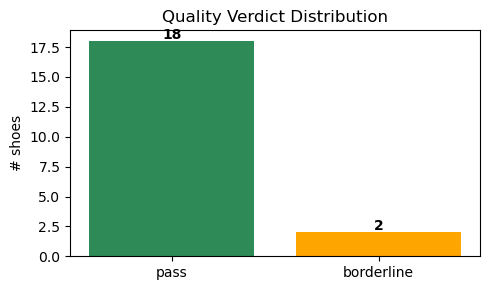

In [84]:
# ── G.3  Verdict summary bar chart ─────────────────────────────────────────────

verdict_colors = {"pass": "seagreen", "borderline": "orange", "reject": "crimson"}
counts = df_all["verdict"].value_counts()

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(counts.index, counts.values,
              color=[verdict_colors.get(v, "grey") for v in counts.index])
ax.set_ylabel("# shoes")
ax.set_title("Quality Verdict Distribution")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
            str(v), ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(cfg.artifact_dir / "verdict_distribution.png", dpi=150,
            bbox_inches="tight")
plt.show()

---

## Section H — Reporting & Export

Persist the unified quality table and configuration so results are
reproducible and downstream pipelines can filter by verdict.

**Outputs saved to** `cfg.artifact_dir`:

| file | format | contents |
|---|---|---|
| `quality_report.csv` | CSV | full table, one row per shoe |
| `quality_report.parquet` | Parquet | same, columnar (fast reload) |
| `thresholds.json` | JSON | thresholds used for this run |

In [85]:
# ── H.1  Export quality report ─────────────────────────────────────────────────

import json

# CSV
csv_path = cfg.artifact_dir / "quality_report.csv"
df_all.to_csv(csv_path, index=False)
log.info("Saved  %s", csv_path)

# Parquet (if pyarrow available, else skip gracefully)
parquet_path = cfg.artifact_dir / "quality_report.parquet"
try:
    df_all.to_parquet(parquet_path, index=False)
    log.info("Saved  %s", parquet_path)
except ImportError:
    log.warning("pyarrow not installed – skipping parquet export.")

# Thresholds JSON — turntable-specific
thresholds = {
    # Segmentation
    "min_seg_consistency":       cfg.min_seg_consistency,
    "fg_area_tiny":              cfg.fg_area_tiny,
    "fg_area_huge":              cfg.fg_area_huge,
    # COLMAP reconstruction
    "min_registration_rate":     cfg.min_registration_rate,
    "max_mean_reproj_error":     cfg.max_mean_reproj_error,
    "min_sparse_points":         cfg.min_sparse_points,
    "max_cam_radius_cv":         cfg.max_cam_radius_cv,
    # Orbit shape (turntable)
    "min_pca_ratio_12":          cfg.min_pca_ratio_12,
    "max_pca_ratio_13":          cfg.max_pca_ratio_13,
    # Orbit coverage
    "min_orbit_coverage":        cfg.min_orbit_coverage,
    "max_orbit_gap_deg":         cfg.max_orbit_gap_deg,
    "max_orbit_thickness_ratio": cfg.max_orbit_thickness_ratio,
}
thresholds_path = cfg.artifact_dir / "thresholds.json"
thresholds_path.write_text(json.dumps(thresholds, indent=2))
log.info("Saved  %s", thresholds_path)

print(f"\n✓ All artefacts saved to {cfg.artifact_dir}")

16:05:29  INFO      Saved  /data/abelde/projects/active/Shell_Gaussian/artifacts/quality_report.csv
16:05:29  WARNING   pyarrow not installed – skipping parquet export.
16:05:29  INFO      Saved  /data/abelde/projects/active/Shell_Gaussian/artifacts/thresholds.json



✓ All artefacts saved to /data/abelde/projects/active/Shell_Gaussian/artifacts


---

## Section I — Human Inspection Helpers

Interactive cells for drilling into **borderline** or **rejected** shoes.
Each helper renders a visual summary so you can decide whether to promote,
demote, or leave the automated verdict as-is.

- **I.1** — List shoes by verdict with top failure reasons
- **I.2** — Per-shoe deep-dive: sample masks, orbit-plane polar plot,
  turntable-specific metrics table, and flag reasons
- **I.3** — Quick image grid for any shoe

In [86]:
# ── I.1  List shoes by verdict ─────────────────────────────────────────────────

for v in ["reject", "borderline", "pass"]:
    subset = df_all[df_all["verdict"] == v]
    print(f"\n{'='*60}")
    print(f"  {v.upper()}  ({len(subset)} shoes)")
    print(f"{'='*60}")
    for _, r in subset.iterrows():
        print(f"  • {r['shoe_id']:55s}  {r['reasons']}")


  REJECT  (0 shoes)

  BORDERLINE  (2 shoes)
  • Air-Jordan-1-Retro-High-Og-White-Cement-Gs               mean_reproj_error=2668.97 > 2.0
  • Ugg-Bailey-Bow-Ii-Boot-Ribbon-Red-Kids                   frac_multiblob=0.53 > 0.50

  PASS  (18 shoes)
  • Adidas-Yeezy-Boost-350-V2-Desert-Sage-Infant             —
  • Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Infants  —
  • Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids     —
  • Air-Jordan-1-Mid-Wear-Away-Chicago-Gs                    —
  • Air-Jordan-1-Retro-High-Hyper-Royal-Smoke-Grey-Gs        —
  • Air-Jordan-1-Retro-High-Og-Washed-Black-Gs               —
  • Air-Jordan-12-Retro-Arctic-Punch-Gs                      —
  • Air-Jordan-13-Retro-Houndstooth-Gs                       —
  • Air-Jordan-5-Retro-Plaid-Gs                              —
  • Air-Jordan-6-Retro-Washed-Denim-2022-Gs                  —
  • Birkenstock-Boston-Suede-Stone-Coin                      —
  • Crocs-Classic-Clog-Cinnamon-Toast-Crunch                

In [87]:
# ── I.2  Per-shoe deep-dive dashboard ──────────────────────────────────────────

def shoe_dashboard(shoe_id: str):
    """Four-panel visual summary for one shoe (turntable-aware)."""
    shoe_dir = cfg.data_root / shoe_id
    row = df_all[df_all["shoe_id"] == shoe_id].iloc[0]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{shoe_id}  —  verdict: {row['verdict']}", fontsize=13,
                 fontweight="bold")

    # ── (a) Sample masked images ───────────────────────────────────────
    ax = axes[0, 0]
    img_paths = sorted((shoe_dir / "images").glob("*"))[:4]
    mask_paths = sorted((shoe_dir / "masks").glob("*"))[:4]
    if img_paths and mask_paths:
        strip = []
        for ip, mp in zip(img_paths, mask_paths):
            img = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
            msk = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
            msk3 = np.stack([msk]*3, axis=-1)
            composite = (img.astype(float) * (msk3.astype(float)/255.0)
                         ).astype(np.uint8)
            h, w = composite.shape[:2]
            scale = 200 / h
            composite = cv2.resize(composite,
                                   (int(w*scale), int(h*scale)))
            strip.append(composite)
        montage = np.concatenate(strip, axis=1)
        ax.imshow(montage)
    ax.set_title("Sample masked images")
    ax.axis("off")

    # ── (b) Orbit-plane azimuth polar plot ─────────────────────────────
    ax = axes[0, 1]
    ax.remove()
    ax = fig.add_subplot(2, 2, 2, projection="polar")
    colmap_dir = shoe_dir / "colmap"
    images_txt = colmap_dir / "images.txt"
    if images_txt.is_file():
        images = parse_images_txt(images_txt)
        centers = np.array([camera_center_from_image(im) for im in images],
                           dtype=float)
        orbit = fit_orbit_frame(centers)
        # Use object centre from sparse points when available
        pts_txt = colmap_dir / "points3D.txt"
        try:
            pts = parse_points3d_txt(pts_txt)
            obj_c = np.mean([p.xyz for p in pts], axis=0) if pts else centers.mean(0)
        except Exception:
            obj_c = centers.mean(axis=0)
        rel = centers - obj_c
        u = rel @ orbit["axis_u"]
        v = rel @ orbit["axis_v"]
        azim = np.arctan2(v, u)
        r = np.sqrt(u * u + v * v)
        ax.scatter(azim, r, s=30, c="steelblue")
        ax.set_title("Cam azimuth (orbit plane)", pad=12)
    else:
        ax.set_title("(no COLMAP data)")

    # ── (c) Key metrics table (turntable-focused) ──────────────────────
    ax = axes[1, 0]
    ax.axis("off")
    metrics = [
        ("registration_rate",    f"{row.get('registration_rate', np.nan):.2f}"),
        ("mean_reproj_error",    f"{row.get('mean_reproj_error', np.nan):.3f}"),
        ("n_sparse_points",      f"{row.get('n_sparse_points', np.nan):.0f}"),
        ("orbit_coverage",       f"{row.get('azimuth_coverage', np.nan):.2f}"),
        ("max_orbit_gap",        f"{row.get('max_azimuth_gap_deg', np.nan):.1f}°"),
        ("orbit_thickness",      f"{row.get('orbit_thickness_ratio', np.nan):.4f}"),
        ("cam_radius_cv",        f"{row.get('cam_radius_cv', np.nan):.3f}"),
        ("pca_12 (ring)",        f"{row.get('pca_ratio_12', np.nan):.4f}"),
        ("pca_13 (planar)",      f"{row.get('pca_ratio_13', np.nan):.4f}"),
        ("seg_consistency",      f"{row.get('seg_consistency_score', np.nan):.3f}"),
    ]
    table = ax.table(cellText=metrics, colLabels=["metric", "value"],
                     loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.3)
    ax.set_title("Key metrics")

    # ── (d) Reasons text ───────────────────────────────────────────────
    ax = axes[1, 1]
    ax.axis("off")
    reason_text = row["reasons"].replace("; ", "\n• ")
    if reason_text != "—":
        reason_text = "• " + reason_text
    ax.text(0.05, 0.95, reason_text, transform=ax.transAxes,
            fontsize=10, verticalalignment="top", family="monospace",
            wrap=True)
    ax.set_title("Flag reasons")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(cfg.artifact_dir / f"dashboard_{shoe_id}.png", dpi=120,
                bbox_inches="tight")
    plt.show()

log.info("shoe_dashboard() helper defined.")

16:05:29  INFO      shoe_dashboard() helper defined.


16:05:29  INFO      Generating dashboards for 2 flagged shoes ...


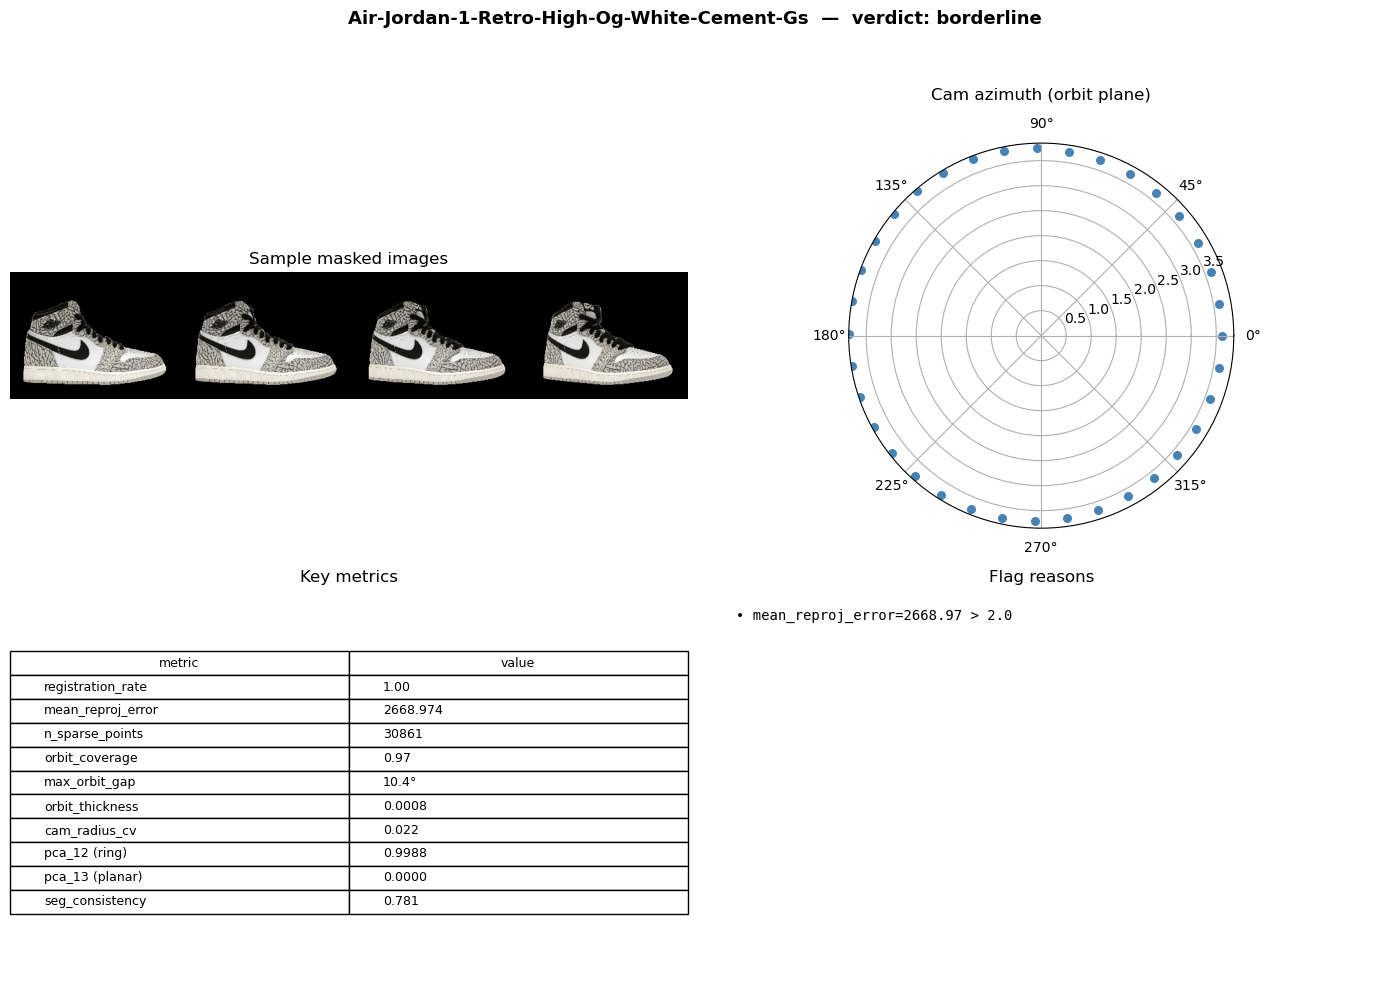

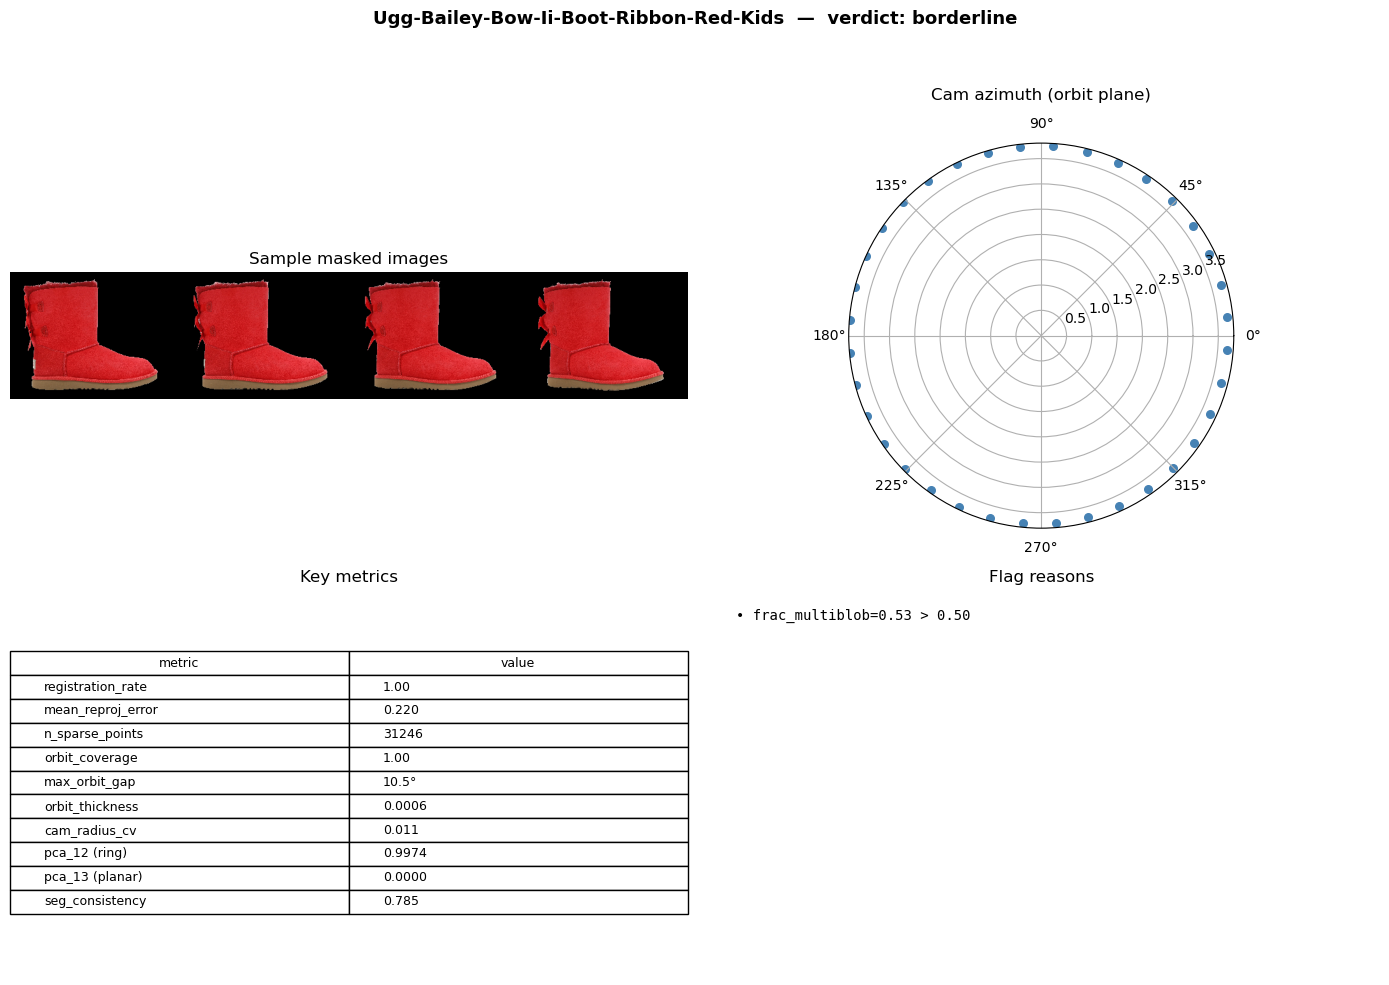

In [88]:
# ── I.2b  Render dashboards for non-passing shoes ─────────────────────────────

flagged = df_all[df_all["verdict"] != "pass"]["shoe_id"].tolist()
if flagged:
    log.info("Generating dashboards for %d flagged shoes ...", len(flagged))
    for sid in flagged:
        shoe_dashboard(sid)
else:
    log.info("All shoes passed — no dashboards to render.")

In [89]:
# ── I.3  Quick image grid helper ────────────────────────────────────────────────

def show_image_grid(shoe_id: str, n: int = 12, figsize=(16, 8)):
    """Display first n images for a shoe in a grid."""
    img_dir = cfg.data_root / shoe_id / "images"
    paths = sorted(img_dir.glob("*"))[:n]
    cols = min(6, n)
    rows = (len(paths) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_2d(axes)
    for idx, ax in enumerate(axes.flat):
        if idx < len(paths):
            img = cv2.cvtColor(cv2.imread(str(paths[idx])), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(paths[idx].name, fontsize=7)
        ax.axis("off")
    fig.suptitle(shoe_id, fontsize=12)
    fig.tight_layout()
    plt.show()

# Example: show grid for first shoe
# show_image_grid(shoes[0])
log.info("show_image_grid() helper defined. Uncomment the line above to use.")

16:05:32  INFO      show_image_grid() helper defined. Uncomment the line above to use.


---

## Section J — Final Report

A concise text summary of the quality audit, interpreted for this
**turntable-style horizontal-orbit** dataset.

* **Good shoe** = clean planar orbit, stable camera radius, complete
  in-plane coverage, good COLMAP support.
* **Suspicious shoe** = broken / incomplete / distorted orbit,
  line-like collapse, thick orbit, or poor COLMAP registration.
* **Not counted as a defect:** missing top/bottom views, near-zero
  third PCA component, low naive elevation diversity.

In [90]:
# ── J.1  Generate final text report ────────────────────────────────────────────

from collections import Counter

n_total = len(df_all)
vc = df_all["verdict"].value_counts()
n_pass       = vc.get("pass", 0)
n_borderline = vc.get("borderline", 0)
n_reject     = vc.get("reject", 0)

# Count individual failure reasons
all_reasons = []
for reasons_str in df_all["reasons"]:
    if reasons_str != "—":
        for r in reasons_str.split("; "):
            metric_name = r.split("=")[0].strip()
            all_reasons.append(metric_name)
reason_counts = Counter(all_reasons).most_common()

# Build report
lines = []
lines.append("=" * 65)
lines.append("  PREPROCESSING QUALITY REPORT  (turntable dataset)")
lines.append("=" * 65)
lines.append("")
lines.append(f"  Dataset:       {cfg.data_root}")
lines.append(f"  Capture type:  horizontal turntable orbit")
lines.append(f"  Total shoes:   {n_total}")
lines.append(f"  Pass:          {n_pass:3d}  ({100*n_pass/n_total:.0f}%)")
lines.append(f"  Borderline:    {n_borderline:3d}  ({100*n_borderline/n_total:.0f}%)")
lines.append(f"  Reject:        {n_reject:3d}  ({100*n_reject/n_total:.0f}%)")
lines.append("")
lines.append("-" * 65)
lines.append("  MOST COMMON FAILURE MODES")
lines.append("-" * 65)
if reason_counts:
    for metric, count in reason_counts:
        lines.append(f"    {metric:40s}  {count:3d} shoes")
else:
    lines.append("    (none — all shoes passed)")
lines.append("")
lines.append("-" * 65)
lines.append("  INTERPRETATION (turntable-specific)")
lines.append("-" * 65)
lines.append("  Good shoe  = planar camera ring, stable radius,")
lines.append("               complete in-plane coverage, clean masks.")
lines.append("  Suspicious = broken/incomplete orbit, line-like collapse,")
lines.append("               thick orbit, poor COLMAP registration.")
lines.append("  NOT defects: missing top/bottom views, near-zero pca_13,")
lines.append("               low naive elevation diversity.")
lines.append("")
lines.append("-" * 65)
lines.append("  RECOMMENDED ACTIONS")
lines.append("-" * 65)
if n_reject > 0:
    rejected = df_all[df_all["verdict"] == "reject"]["shoe_id"].tolist()
    lines.append(f"  1. Investigate rejected shoes ({n_reject}):")
    for sid in rejected:
        lines.append(f"       - {sid}")
    lines.append("     Run shoe_dashboard(shoe_id) for visual inspection.")
if n_borderline > 0:
    lines.append(f"  2. Review borderline shoes ({n_borderline}):")
    borderline_ids = df_all[df_all["verdict"] == "borderline"]["shoe_id"].tolist()
    for sid in borderline_ids:
        lines.append(f"       - {sid}")
    lines.append("     These may be acceptable depending on your quality bar.")
if n_pass == n_total:
    lines.append("  All shoes passed. Ready for reconstruction.")
lines.append("")
lines.append("=" * 65)

report_text = "\n".join(lines)
print(report_text)

# Save to file
report_path = cfg.artifact_dir / "quality_report.txt"
report_path.write_text(report_text)
log.info("Report saved to %s", report_path)

16:05:32  INFO      Report saved to /data/abelde/projects/active/Shell_Gaussian/artifacts/quality_report.txt


  PREPROCESSING QUALITY REPORT  (turntable dataset)

  Dataset:       /data/abelde/datasets/raw/golden_set
  Capture type:  horizontal turntable orbit
  Total shoes:   20
  Pass:           18  (90%)
  Borderline:      2  (10%)
  Reject:          0  (0%)

-----------------------------------------------------------------
  MOST COMMON FAILURE MODES
-----------------------------------------------------------------
    mean_reproj_error                           1 shoes
    frac_multiblob                              1 shoes

-----------------------------------------------------------------
  INTERPRETATION (turntable-specific)
-----------------------------------------------------------------
  Good shoe  = planar camera ring, stable radius,
               complete in-plane coverage, clean masks.
  Suspicious = broken/incomplete orbit, line-like collapse,
               thick orbit, poor COLMAP registration.
  NOT defects: missing top/bottom views, near-zero pca_13,
               low naiv

---

**End of notebook.** All artifacts are in the `artifacts/` directory.

Use `shoe_dashboard(shoe_id)` or `show_image_grid(shoe_id)` above to
interactively inspect any shoe that needs attention.

**Reminder:** This analysis is calibrated for a turntable-style horizontal
orbit.  Near-zero `pca_ratio_13` and low elevation diversity are expected
properties of the capture process, not quality defects.